Cell 1: Start!

## How to run this notebook

Cells are in linear top-to-bottom order. Just run them one by one (`Shift+Enter`), or hit **Run All**.

The notebook is divided into setup cells, then **7 numbered steps**:

| Step | What it does |
|---|---|
| Setup | Imports, classes, dataset load, pipeline config, cleanup of stale files |
| Step 1 | Train Gemini-judge LoRA (needs `GEMINI_API_KEY`) |
| Step 2 | Train Naive LoRA (no judge — ablation baseline) |
| Step 3 | Train Claude-judge LoRA (needs `ANTHROPIC_API_KEY1`) |
| Step 4 | Tag any legacy untagged checkpoints (usually a no-op) |
| Step 5 | Re-inference + evaluation — produces metrics + figures |
| Step 6 | RLAIF Stage 2 — depends on Step 5's outputs |
| Step 7 | (Optional) Plot original-vs-finetuned forecasts |

### Held-out evaluation
The fine-tuning pipelines (Steps 1–3) only see the first **85 %** of the series (`input_data_train`). The held-out **last 15 %** is used only at evaluation time. All F1 numbers in Steps 5 and 6 are computed on the held-out horizon only.

### If you change the dataset
**Re-run the cleanup cell at the end of Setup** — otherwise old `.pth` checkpoints and `plot_data_*.jsonl` files from a previous run will contaminate the new evaluation.

### What you can safely skip
- **Step 1** if you don't have a Gemini API key — Steps 2 and 3 don't need it.
- **Step 3** if you don't have an Anthropic API key.
- **Step 6** if you only want the headline metrics (Step 5 reports those).
- **Step 7** if you don't need plots.

In [1]:
import sys, apache_beam as beam
print("Python:", sys.version)
print("Beam:", beam.__version__)

Python: 3.11.14 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 18:30:03) [MSC v.1929 64 bit (AMD64)]
Beam: 2.67.0


In [2]:
# FIX: Beam 2.67 bug — "unhashable type: 'list'" in stateful DoFns
from apache_beam.runners.worker import bundle_processor

_orig_create = bundle_processor.FnApiUserStateContext._create_state

def _safe_get_state(self, *args):
    # FIX: instead of converting args to hashable types (which fails for
    # Beam's internal Protobuf state key objects), use repr() as the cache key.
    # repr() always returns a plain string — guaranteed hashable.
    try:
        # Try the normal path first (fast)
        state_handle = self._all_states.get(args)
        if state_handle is None:
            state_handle = self._all_states[args] = _orig_create(self, *args)
        return state_handle
    except TypeError:
        # args contains something unhashable (Beam 2.67 bug).
        # Fall back: use string representation as key.
        str_key = repr(args)
        state_handle = self._all_states.get(str_key)
        if state_handle is None:
            state_handle = self._all_states[str_key] = _orig_create(self, *args)
        return state_handle

bundle_processor.FnApiUserStateContext.get_state = _safe_get_state
print("Patched Beam 2.67 state hashing bug")

Patched Beam 2.67 state hashing bug


In [3]:
# FIX #2: Beam 2.67 — "unhashable type: 'list'" in _collect_written_timers
from apache_beam.runners.portability.fn_api_runner import fn_runner

def _h(obj):
    """Make ANY unhashable object hashable."""
    try:
        hash(obj)
        return obj
    except TypeError:
        if hasattr(obj, '__iter__'):
            return tuple(_h(x) for x in obj)
        return id(obj)

_src = '''
@staticmethod
def _collect_written_timers(bundle_context_manager):
    timer_watermark_data = {}
    newly_set_timers = {}
    for (transform_id, timer_family_id) in bundle_context_manager.stage.timers:
        written_timers = bundle_context_manager.get_buffer(
            create_buffer_id(timer_family_id, kind='timers'), transform_id)
        assert isinstance(written_timers, ListBuffer)
        timer_coder_impl = bundle_context_manager.get_timer_coder_impl(
            transform_id, timer_family_id)
        if not written_timers.cleared:
            timers_by_key_tag_and_window = {}
            for elements_timers in written_timers:
                for decoded_timer in timer_coder_impl.decode_all(elements_timers):
                    key_tag_win = (
                        _h(decoded_timer.user_key),
                        _h(decoded_timer.dynamic_timer_tag),
                        _h(decoded_timer.windows[0]))
                    if not decoded_timer.clear_bit:
                        timers_by_key_tag_and_window[key_tag_win] = decoded_timer
                    elif (decoded_timer.clear_bit and
                          key_tag_win in timers_by_key_tag_and_window):
                        del timers_by_key_tag_and_window[key_tag_win]

            out = create_OutputStream()
            for decoded_timer in timers_by_key_tag_and_window.values():
                if not decoded_timer.clear_bit:
                    timer_coder_impl.encode_to_stream(decoded_timer, out, True)
                    if (transform_id, timer_family_id) not in timer_watermark_data:
                        timer_watermark_data[(transform_id,
                                              timer_family_id)] = timestamp.MAX_TIMESTAMP
                    timer_watermark_data[(transform_id, timer_family_id)] = min(
                        timer_watermark_data[(transform_id, timer_family_id)],
                        decoded_timer.hold_timestamp)
            if (transform_id, timer_family_id) not in timer_watermark_data:
                continue
            newly_set_timers[(transform_id, timer_family_id)] = (
                ListBuffer(coder_impl=timer_coder_impl),
                timer_watermark_data[(transform_id, timer_family_id)])
            newly_set_timers[(transform_id, timer_family_id)][0].append(out.get())
            written_timers.clear()

    return timer_watermark_data, newly_set_timers
'''

_ns = dict(fn_runner.__dict__)
_ns['_h'] = _h
exec(compile(_src, "<beam_patch>", "exec"), _ns)
fn_runner.FnApiRunner._collect_written_timers = _ns['_collect_written_timers']
print("Patched _collect_written_timers")
print("Verify:", fn_runner.FnApiRunner._collect_written_timers.__code__.co_filename)

Patched _collect_written_timers
Verify: <beam_patch>


Cell 2: Ordered Sliding Window

In [4]:
import logging

import apache_beam as beam
from apache_beam.coders import BooleanCoder
from apache_beam.coders import PickleCoder
from apache_beam.coders import TimestampCoder
from apache_beam.transforms.timeutil import TimeDomain
from apache_beam.transforms.userstate import OrderedListStateSpec
from apache_beam.transforms.userstate import ReadModifyWriteStateSpec
from apache_beam.transforms.userstate import TimerSpec
from apache_beam.transforms.userstate import on_timer
from apache_beam.utils.timestamp import MAX_TIMESTAMP
from apache_beam.utils.timestamp import Timestamp

_LOGGER = logging.getLogger(__name__)
logging.basicConfig(level=logging.INFO)
_LOGGER.setLevel(logging.INFO)


class OrderedSlidingWindowFn(beam.DoFn):

  ORDERED_BUFFER_STATE = OrderedListStateSpec('ordered_buffer', PickleCoder())
  WINDOW_TIMER = TimerSpec('window_timer', TimeDomain.WATERMARK)
  TIMER_STATE = ReadModifyWriteStateSpec('timer_state', BooleanCoder())
  EARLIEST_TS_STATE = ReadModifyWriteStateSpec('earliest_ts', TimestampCoder())

  def __init__(self, window_size, slide_interval):
    self.window_size = window_size
    self.slide_interval = slide_interval

  def start_bundle(self):
    _LOGGER.debug("start bundle")

  def finish_bundle(self):
    _LOGGER.debug("finish bundle")

  def process(
      self,
      element,
      timestamp=beam.DoFn.TimestampParam,
      ordered_buffer=beam.DoFn.StateParam(ORDERED_BUFFER_STATE),
      window_timer=beam.DoFn.TimerParam(WINDOW_TIMER),
      timer_state=beam.DoFn.StateParam(TIMER_STATE),
      earliest_ts_state=beam.DoFn.StateParam(EARLIEST_TS_STATE)):

    _, value = element
    ordered_buffer.add((timestamp, value))

    _LOGGER.debug("receive %s at %s", element, timestamp)
    timer_started = timer_state.read()

    earliest = earliest_ts_state.read()
    if not earliest or earliest > timestamp:
      earliest_ts_state.write(timestamp)

    if not timer_started:
      earliest_ts_state.write(timestamp)

      first_slide_start = int(
          timestamp.micros / 1e6 // self.slide_interval) * self.slide_interval
      first_slide_start_ts = Timestamp.of(first_slide_start)

      first_window_end_ts = first_slide_start_ts + self.window_size
      _LOGGER.debug("set timer to %s", first_window_end_ts)
      window_timer.set(first_window_end_ts)

      timer_state.write(True)

    return []

  @on_timer(WINDOW_TIMER)
  def on_timer(
      self,
      key=beam.DoFn.KeyParam,
      fire_ts=beam.DoFn.TimestampParam,
      ordered_buffer=beam.DoFn.StateParam(ORDERED_BUFFER_STATE),
      window_timer=beam.DoFn.TimerParam(WINDOW_TIMER),
      timer_state=beam.DoFn.StateParam(TIMER_STATE),
      earliest_ts_state=beam.DoFn.StateParam(EARLIEST_TS_STATE)):
    _LOGGER.debug("timer fire at %s", fire_ts)
    window_end_ts = fire_ts
    window_start_ts = window_end_ts - self.window_size

    window_values = list(
        ordered_buffer.read_range(window_start_ts, window_end_ts))

    _LOGGER.debug(
        "window start: %s, window end: %s", window_start_ts, window_end_ts)
    _LOGGER.debug("windowed data in buffer %s", str(window_values))
    if window_values:
      yield (key, (window_start_ts, window_end_ts, window_values))

    next_window_end_ts = fire_ts + self.slide_interval
    next_window_start_ts = window_start_ts + self.slide_interval

    earliest_ts = earliest_ts_state.read()
    ordered_buffer.clear_range(earliest_ts, next_window_start_ts)

    remaining_data = list(
        ordered_buffer.read_range(next_window_start_ts, MAX_TIMESTAMP))

    if not remaining_data:
      timer_state.clear()
      earliest_ts_state.write(next_window_start_ts)
      return

    _LOGGER.debug("set timer to %s", next_window_end_ts)
    window_timer.set(next_window_end_ts)


class FillGapsFn(beam.DoFn):
  def __init__(self, expected_interval: float):
    """
    Args:
      expected_interval: The expected time delta between elements, in seconds.
    """
    self.expected_interval = expected_interval

  def process(self, element):
    key, (window_start_ts, window_end_ts, window_elements) = element

    received_data = {
        round(float(ts.micros / 1e6), 5): val
        for ts, val in window_elements
    }

    start_sec = float(window_start_ts.micros / 1e6)
    end_sec = float(window_end_ts.micros / 1e6)

    filled_values = []
    current_ts_sec = start_sec

    while current_ts_sec < end_sec:
      lookup_ts = round(current_ts_sec, 5)

      if lookup_ts in received_data:
        filled_values.append(float(received_data[lookup_ts]))
      else:
        filled_values.append('NaN')

      current_ts_sec += self.expected_interval

    yield (key, (window_start_ts, window_end_ts, filled_values))


Cell 3: Model Handler

In [5]:
import apache_beam as beam
from apache_beam.ml.inference.base import ModelHandler
import timesfm
import logging
import numpy as np
import os
from google.cloud import storage
from apache_beam.io.gcp.gcsio import GcsIO
from apache_beam.utils.timestamp import Timestamp

class LatestModelCheckpointLoader(beam.PTransform):
    """A PTransform that finds the latest model checkpoint in a GCS path."""
    def __init__(self, gcs_bucket, gcs_prefix):
        self.gcs_bucket = gcs_bucket
        self.gcs_prefix = gcs_prefix

    def expand(self, pcoll):
        return pcoll | "FindLatestModel" >> beam.Map(self._find_latest_model_path)

    def _find_latest_model_path(self, _):
        try:
            storage_client = storage.Client()
            blobs = storage_client.list_blobs(self.gcs_bucket, prefix=self.gcs_prefix)
            # Filter for model files and find the most recent one
            model_blobs = [b for b in blobs if b.name.endswith(".pth")]
            latest_blob = max(model_blobs, key=lambda b: b.time_created, default=None)

            if latest_blob:
                path = f"gs://{self.gcs_bucket}/{latest_blob.name}"
                logging.info(f"Found latest finetuned model at: {path}")
                return path
        except Exception as e:
            logging.error(f"Error finding latest model in GCS: {e}")

        # Return a path to the base model if no finetuned one exists or an error occurs
        base_model = "google/timesfm-1.0-200m-pytorch"
        logging.info(f"No finetuned model found. Using base model: {base_model}")
        return base_model

class DynamicTimesFmModelHandler(ModelHandler[np.ndarray, np.ndarray, timesfm.TimesFm]):
    """
    A model handler that loads a TimesFM model from a dynamic path (GCS or Hugging Face).
    The model path is provided as a side input to RunInference.
    """
    def __init__(self, model_uri: str, hparams):
        self._hparams = hparams
        self._model = None
        self._model_uri = model_uri
        self._context_len = hparams.context_len
        self._horizon_len = hparams.horizon_len

    def load_model(self) -> timesfm.TimesFm:
        logging.info(f"Loading TimesFM model from path: {self._model_uri}...")

        checkpoint_config = {}
        if self._model_uri.startswith("gs://"):
            try:
                gcs = GcsIO()
                file_name = os.path.basename(self._model_uri)
                local_path = f"/tmp/{file_name}"
                with gcs.open(self._model_uri, 'rb') as f_in, open(local_path, 'wb') as f_out:
                    f_out.write(f_in.read())
                checkpoint_config['path'] = local_path
                logging.info(f"Downloaded model from GCS to {local_path}")
            except Exception as e:
                logging.error(f"Failed to download model from GCS: {e}.")
                raise e
        elif os.path.isfile(self._model_uri):
            checkpoint_config['path'] = self._model_uri
            logging.info(f"Loading local checkpoint: {self._model_uri}")
        else:
            checkpoint_config['huggingface_repo_id'] = self._model_uri

        # ── FIX: actually create and return the model ──
        tfm = timesfm.TimesFm(
            hparams=self._hparams,
            checkpoint=timesfm.TimesFmCheckpoint(**checkpoint_config)
        )
        self._model = tfm
        logging.info("Model loaded successfully.")
        return tfm

    def update_model_path(self, model_path: str):
        """
        This method is called by RunInference when a new model metadata is available
        from the side input. It updates the model URI that `load_model` will use.
        """
        if not model_path:
            logging.info("Received an empty model path update. No action taken.")
            return
        logging.info(f"Received model update. New model URI: {model_path}")
        self._model_uri = model_path
        self._model = self.load_model()
        logging.info("Model has been updated in the handler.")

    def run_inference(self, batch, model, inference_args=None):
        if self._model is None:
            if self._model_uri.endswith('.pth') and os.path.isfile(self._model_uri):
                import torch
                base = timesfm.TimesFm(
                    hparams=self._hparams,
                    checkpoint=timesfm.TimesFmCheckpoint(
                        huggingface_repo_id="google/timesfm-1.0-200m-pytorch"
                    )
                )
                # FIX: inject LoRA adapters BEFORE loading weights
                inject_lora(base._model, rank=4, alpha=1.0)
                state = torch.load(self._model_uri, map_location='cpu')
                try:
                    
                    missing, unexpected = base._model.load_state_dict(state, strict=False)
                    logging.info(
                        f"Loaded LoRA weights from {self._model_uri} | "
                        f"missing={len(missing)} unexpected={len(unexpected)}"
                    )
                    self._model = base
                except RuntimeError as e:
                    logging.warning(
                        f"Could not load LoRA weights ({e}). "
                        f"Using base model instead."
                    )
                    self._model = base
            else:
                self.load_model()

        # FIX: prefer the model Beam passed in (it's the canonical
        # output of load_model()).  Fall back to self._model only
        # for the .pth-LoRA branch above, which writes to self._model
        # directly.
        tfm = model if model is not None else self._model
        anomalies_found = []
        key, (window_start_ts, _, values_array) = batch[0]

        current_context = np.array(values_array[:self._context_len])
        actual_horizon_values = np.array(
            values_array[self._context_len:self._context_len + self._horizon_len])

        print("Current context shape:", current_context.shape)
        print("Actual horizon values shape:", actual_horizon_values.shape)

        point_forecast, experimental_quantile_forecast = tfm.forecast(
            [current_context],
            freq=[0],
        )

        current_predicted_horizon_values = (
            point_forecast[0, :, 0] if point_forecast.ndim == 3 else point_forecast[0])

        current_q20_values = experimental_quantile_forecast[0, :, 2]
        current_q30_values = experimental_quantile_forecast[0, :, 3]
        current_q70_values = experimental_quantile_forecast[0, :, 7]
        current_q80_values = experimental_quantile_forecast[0, :, 8]

        for j in range(len(actual_horizon_values)):
            current_actual = actual_horizon_values[j]

            point_Q1 = np.nanmean([current_q20_values[j], current_q30_values[j]])
            point_Q3 = np.nanmean([current_q70_values[j], current_q80_values[j]])
            point_IQR = point_Q3 - point_Q1

            upper_thresh = point_Q3 + 1.5 * point_IQR
            lower_thresh = point_Q1 - 1.5 * point_IQR

            if current_actual > upper_thresh or current_actual < lower_thresh:
                score = ((current_actual - upper_thresh) / point_IQR
                         if current_actual > upper_thresh
                         else (lower_thresh - current_actual) / point_IQR)

                anomaly_timestamp_seconds = (
                    window_start_ts.micros / 1e6) + (self._context_len + j)
                index_in_window = self._context_len + j

                anomalies_found.append({
                    'key': key,
                    'timestamp': Timestamp(anomaly_timestamp_seconds),
                    'index_in_window': index_in_window,
                    'actual_value': current_actual,
                    'predicted_value': current_predicted_horizon_values[j],
                    'is_anomaly': True,
                    'outlier_score': score,
                    'lower_bound': lower_thresh,
                    'upper_bound': upper_thresh,
                })

        payload = {
            "start_ts_micros": window_start_ts.micros,
            "predicted_values": current_predicted_horizon_values.tolist(),
            "q20_values": current_q20_values.tolist(),
            "q30_values": current_q30_values.tolist(),
            "q70_values": current_q70_values.tolist(),
            "q80_values": current_q80_values.tolist(),
            "anomalies": anomalies_found,
            "actual_horizon_values": actual_horizon_values.tolist()
        }
        orig_key, (ws_ts, we_ts, orig_vals) = batch[0]
        serializable_batch0 = (
            orig_key,
            (int(ws_ts.micros), int(we_ts.micros), list(orig_vals))
        )
        result_with_context = (serializable_batch0, payload)
        return [result_with_context]

 See https://github.com/google-research/timesfm/blob/master/README.md for updated APIs.
Loaded PyTorch TimesFM, likely because python version is 3.11.14 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 18:30:03) [MSC v.1929 64 bit (AMD64)].


C:\Users\robotics\AppData\Roaming\Python\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Cell 4: LLM Classifier

In [6]:
import apache_beam as beam
import google.generativeai as genai
import logging
import os
import re
import json
import numpy as np
from apache_beam.utils.timestamp import Timestamp
from dotenv import load_dotenv
from apache_beam.transforms.userstate import BagStateSpec
from apache_beam.coders.coders import PickleCoder
from apache_beam.transforms.userstate import BagStateSpec, ReadModifyWriteStateSpec, TimerSpec, on_timer


class CustomJsonEncoderForLLM(json.JSONEncoder):
    """Encodes special types like Timestamp and numpy objects into JSON."""
    def default(self, obj):
        if isinstance(obj, Timestamp):
            return {'__timestamp__': True, 'micros': obj.micros}
        if isinstance(obj, np.integer):
            return int(obj)
        if isinstance(obj, np.floating):
            return float(obj)
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        return super().default(obj)

def custom_json_decoder(dct):
    """Decodes a Timestamp object from our custom dict format."""
    if '__timestamp__' in dct:
        return Timestamp(micros=dct['micros'])
    return dct

class JsonCoderWithNumpyAndTimestamp(beam.coders.Coder):
    """A custom Beam Coder that handles JSON serialization for Timestamps and numpy types."""
    def encode(self, value):
        return json.dumps(value, cls=CustomJsonEncoderForLLM).encode('utf-8')

    def decode(self, encoded):
        return json.loads(encoded.decode('utf-8'), object_hook=custom_json_decoder)

    def is_deterministic(self):
        return True


class LLMClassifierFn(beam.DoFn):
    """
    Takes an anomaly, formats a detailed prompt with surrounding context,
    calls the Gemini model to classify it, and routes the original data
    based on the model's decision.
    """

    DEFERRED_ANOMALIES_STATE = BagStateSpec(
        'deferred_anomalies', coder=JsonCoderWithNumpyAndTimestamp())
    YIELD_BUFFER_STATE = ReadModifyWriteStateSpec('yield_buffer', PickleCoder())
    EXPIRY_TIMER = TimerSpec('expiry', beam.TimeDomain.WATERMARK)
    LAST_YIELDED_TIMESTAMP_STATE = ReadModifyWriteStateSpec('last_yielded_ts', PickleCoder())

    def __init__(self, secret, context_points=25, slide_interval=128, expected_interval_secs=1):
        self.context_points = context_points
        self._model = None
        self.secret = secret
        self.slide_interval = slide_interval
        self.expected_interval_micros = expected_interval_secs * 1_000_000
        self._last_window_data = None

    def setup(self):
        genai.configure(api_key=self.secret)
        logging.getLogger().setLevel(logging.INFO)
        generation_config = {
            "temperature": 0.2,
            "top_p": 1,
            "top_k": 1,
            "max_output_tokens": 256,
            "response_mime_type": "application/json",
        }
        safety_settings = [
            {"category": "HARM_CATEGORY_HARASSMENT", "threshold": "BLOCK_NONE"},
            {"category": "HARM_CATEGORY_HATE_SPEECH", "threshold": "BLOCK_NONE"},
        ]
        self._model = genai.GenerativeModel(
            model_name="gemini-1.5-flash-latest",
            generation_config=generation_config,
            safety_settings=safety_settings
        )
        logging.info("Gemini Model has been successfully initialized.")

    def _build_prompt(self, anomaly_data, context_before, context_after):
        mean_before = np.mean(context_before) if context_before.size > 0 else 0
        mean_after = np.mean(context_after) if context_after.size > 0 else 0
        std_before = np.std(context_before) if context_before.size > 0 else 0
        std_after = np.std(context_after) if context_after.size > 0 else 0

        # FIX: anomaly timestamp is now stored as int micros — reconstruct for display
        ts_display = Timestamp(micros=int(anomaly_data['timestamp'])) \
            if isinstance(anomaly_data['timestamp'], (int, float)) \
            else anomaly_data['timestamp']

        return f"""
        You are an expert time-series analyst classifying an outlier from NYC taxi pickup data.
        Normal behavior includes daily and weekly cyclical patterns.

        **1. Outlier Context:**
        * **--> The Outlier:**
            * **Timestamp:** {ts_display}
            * **Actual Value:** {anomaly_data['actual_value']:.2f}
            * **Predicted Value:** {anomaly_data['predicted_value']:.2f}
            * **Anomaly Upper Bound:** {anomaly_data['upper_bound']:.2f}
            * **Anomaly Lower Bound:** {anomaly_data['lower_bound']:.2f}

        **2. Data Surrounding the Outlier:**
        * **Data Before ({len(context_before)} points):** {np.round(context_before, 2).tolist()}
        * **Data After ({len(context_after)} points):** {np.round(context_after, 2).tolist()}

        **3. Statistical Context:**
        * **Mean Before:** {mean_before:.2f}
        * **Mean After:** {mean_after:.2f}
        * **Std. Dev. Before:** {std_before:.2f}
        * **Std. Dev. After:** {std_after:.2f}

        **4. Your Task:**

        **Step 1: Analyze the Evidence.** In a few sentences, describe the behavior of the data
        *after* the outlier. Does it quickly revert to the Predicted Value or the Mean Before?
        Or does it establish a new level, closer to the Mean After?

        **Step 2: Make a Decision.** Classify the outlier.
        * **REMOVE:** If it's a transient, one-off event.
        * **KEEP:** If it signifies a sustained shift the model should learn from.

        **Step 3: Provide Final Output.** Respond with a single JSON object only.

        {{
          "reasoning_steps": "Your analysis from Step 1 goes here.",
          "decision": "KEEP or REMOVE",
          "confidence_score": 0.9
        }}
        """
        # ↑ FIX 1: f-string is properly closed here with """
        # FIX 2: confidence_score now has a placeholder value (0.9)
        #         (previously it was blank → "empty expression" SyntaxError)

    def process(self, element,
                deferred_anomalies=beam.DoFn.StateParam(DEFERRED_ANOMALIES_STATE),
                yield_buffer=beam.DoFn.StateParam(YIELD_BUFFER_STATE),
                expiry_timer=beam.DoFn.TimerParam(EXPIRY_TIMER)):

        key, data = element

        # FIX: format_for_llm stores window_start_ts as int micros —
        # reconstruct Timestamp here before use.
        window_start_ts = Timestamp(micros=int(data['window_start_ts_micros']))

        grace_period_secs = self.slide_interval * 2
        expiry_timer.set(window_start_ts + grace_period_secs)
        raw_anomalies = data.get('anomalies', ())
        anomalies_in_window = [dict(a) for a in raw_anomalies] if raw_anomalies else []
        values_in_element = list(data.get('values_array', ()))

        for anomaly in anomalies_in_window:
            # FIX: anomaly['timestamp'] is int micros — reconstruct Timestamp
            # so on_expiry_timer can match it against buffer keys.
            anomaly = dict(anomaly)
            if isinstance(anomaly.get('timestamp'), (int, float)):
                anomaly['timestamp'] = Timestamp(micros=int(anomaly['timestamp']))
            deferred_anomalies.add(anomaly)

        buffer = yield_buffer.read() or {}
        for i, value in enumerate(values_in_element):
            point_timestamp = Timestamp(
                micros=window_start_ts.micros + (i * self.expected_interval_micros))
            buffer[point_timestamp] = value
        yield_buffer.write(buffer)

    @on_timer(EXPIRY_TIMER)
    def on_expiry_timer(
        self,
        deferred_anomalies=beam.DoFn.StateParam(DEFERRED_ANOMALIES_STATE),
        yield_buffer=beam.DoFn.StateParam(YIELD_BUFFER_STATE),
        last_yielded_ts_state=beam.DoFn.StateParam(LAST_YIELDED_TIMESTAMP_STATE)):

        all_anomalies_to_consider = list(deferred_anomalies.read())
        buffered_points_map = yield_buffer.read() or {}

        if not buffered_points_map:
            return

        sorted_points = sorted(buffered_points_map.items())
        all_timestamps = [ts for ts, val in sorted_points]
        all_values = [val for ts, val in sorted_points]

        anomalies_to_process_now = []
        prompts_to_batch = []
        final_deferred = []

        for anomaly_data in all_anomalies_to_consider:
            anomaly_ts = anomaly_data['timestamp']
            try:
                idx_in_full_data = all_timestamps.index(anomaly_ts)

                if (idx_in_full_data + self.context_points) < len(all_values):
                    start_ctx = max(0, idx_in_full_data - self.context_points)
                    end_ctx = idx_in_full_data + self.context_points + 1

                    context_before = np.array(all_values[start_ctx:idx_in_full_data])
                    context_after = np.array(all_values[idx_in_full_data + 1:end_ctx])

                    anomaly_data['index_in_window'] = idx_in_full_data
                    prompt = self._build_prompt(anomaly_data, context_before, context_after)
                    prompts_to_batch.append(prompt)
                    anomalies_to_process_now.append(anomaly_data)
                else:
                    final_deferred.append(anomaly_data)
            except ValueError:
                final_deferred.append(anomaly_data)

        if prompts_to_batch:
            try:
                logging.info(f"Sending a batch of {len(prompts_to_batch)} prompts to the LLM.")
                responses = self._model.generate_content(prompts_to_batch)
                for anomaly_data, response in zip(anomalies_to_process_now, responses):
                    try:
                        response_data = json.loads(response.text)
                        decision = response_data.get('decision', 'KEEP').strip().upper()
                        idx = anomaly_data['index_in_window']
                        if decision == 'REMOVE':
                            logging.warning(
                                f"LLM decided to REMOVE anomaly at {anomaly_data['timestamp']}.")
                            all_values[idx] = anomaly_data['predicted_value']
                    except (json.JSONDecodeError, AttributeError) as e:
                        logging.error(
                            f"Error processing LLM response for {anomaly_data['timestamp']}: {e}.")
            except Exception as e:
                logging.error(f"Error calling LLM with a batch: {e}. Defaulting to KEEP for all.")

        last_yielded_ts = last_yielded_ts_state.read()
        latest_ts_in_batch = None

        for i, (ts, original_val) in enumerate(sorted_points):
            
            if last_yielded_ts is None or ts > last_yielded_ts:
                yield {
                    'timestamp': float(ts.micros / 1e6),  # FIX: int seconds, not Timestamp
                    'value': all_values[i]
                }
                latest_ts_in_batch = ts

        if latest_ts_in_batch:
            last_yielded_ts_state.write(latest_ts_in_batch)

        if latest_ts_in_batch:
            all_buffered_points = yield_buffer.read() or {}
            try:
                last_yielded_index = all_timestamps.index(latest_ts_in_batch)
                context_start_index = max(0, last_yielded_index - self.context_points)
                context_start_ts = all_timestamps[context_start_index]
                pruned_buffer = {
                    ts: val
                    for ts, val in all_buffered_points.items()
                    if ts >= context_start_ts
                }
                yield_buffer.write(pruned_buffer)
            except ValueError:
                logging.warning(
                    f"Could not find last yielded timestamp {latest_ts_in_batch} for pruning.")
                if not final_deferred:
                    yield_buffer.clear()
        elif not final_deferred:
            yield_buffer.clear()

        deferred_anomalies.clear()
        if final_deferred:
            logging.info(f"Re-deferring {len(final_deferred)} anomalies.")
            for anomaly in final_deferred:
                deferred_anomalies.add(anomaly)

Claude Sonnet

In [7]:
!pip install anthropic


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
import anthropic
import apache_beam as beam
import json
import logging
import numpy as np
from apache_beam.utils.timestamp import Timestamp
from apache_beam.transforms.userstate import BagStateSpec, ReadModifyWriteStateSpec, TimerSpec, on_timer
from apache_beam.coders.coders import PickleCoder
 
 
class AnthropicLLMClassifierFn(beam.DoFn):
    """
    Drop-in replacement for LLMClassifierFn that uses Claude Sonnet
    instead of Gemini. Same prompt, same input/output format.
    """
 
    DEFERRED_ANOMALIES_STATE = BagStateSpec(
        'deferred_anomalies', coder=JsonCoderWithNumpyAndTimestamp())
    YIELD_BUFFER_STATE = ReadModifyWriteStateSpec('yield_buffer', PickleCoder())
    EXPIRY_TIMER = TimerSpec('expiry', beam.TimeDomain.WATERMARK)
    LAST_YIELDED_TIMESTAMP_STATE = ReadModifyWriteStateSpec(
        'last_yielded_ts', PickleCoder())
 
    def __init__(self, secret, context_points=25, slide_interval=128,
                 expected_interval_secs=1):
        self.context_points = context_points
        self._client = None
        self.secret = secret
        self.slide_interval = slide_interval
        self.expected_interval_micros = expected_interval_secs * 1_000_000
 
    def setup(self):
        self._client = anthropic.Anthropic(api_key=self.secret)
        logging.info("Anthropic Claude client initialized.")
 
    def _build_prompt(self, anomaly_data, context_before, context_after):
        """Identical prompt to Gemini version for fair comparison."""
        mean_before = np.mean(context_before) if context_before.size > 0 else 0
        mean_after  = np.mean(context_after) if context_after.size > 0 else 0
        std_before  = np.std(context_before) if context_before.size > 0 else 0
        std_after   = np.std(context_after) if context_after.size > 0 else 0
 
        ts_display = Timestamp(micros=int(anomaly_data['timestamp'])) \
            if isinstance(anomaly_data['timestamp'], (int, float)) \
            else anomaly_data['timestamp']
 
        return f"""
        You are an expert time-series analyst classifying an outlier.
        Normal behavior includes daily and weekly cyclical patterns.
 
        **1. Outlier Context:**
        * **Timestamp:** {ts_display}
        * **Actual Value:** {anomaly_data['actual_value']:.2f}
        * **Predicted Value:** {anomaly_data['predicted_value']:.2f}
        * **Anomaly Upper Bound:** {anomaly_data['upper_bound']:.2f}
        * **Anomaly Lower Bound:** {anomaly_data['lower_bound']:.2f}
 
        **2. Data Surrounding the Outlier:**
        * **Data Before ({len(context_before)} points):** {np.round(context_before, 2).tolist()}
        * **Data After ({len(context_after)} points):** {np.round(context_after, 2).tolist()}
 
        **3. Statistical Context:**
        * **Mean Before:** {mean_before:.2f}
        * **Mean After:** {mean_after:.2f}
        * **Std. Dev. Before:** {std_before:.2f}
        * **Std. Dev. After:** {std_after:.2f}
 
        **4. Your Task:**
        **Step 1:** Analyze the data after the outlier. Does it revert or shift?
        **Step 2:** Classify: REMOVE (transient) or KEEP (sustained shift).
        **Step 3:** Respond with ONLY a JSON object, no markdown:
 
        {{
          "reasoning_steps": "Your analysis here.",
          "decision": "KEEP or REMOVE",
          "confidence_score": 0.9
        }}
        """
 
    def _call_claude(self, prompt):
        """Call Claude and parse JSON response."""
        try:
            response = self._client.messages.create(
                model="claude-sonnet-4-20250514",
                max_tokens=256,
                temperature=0.2,
                messages=[{"role": "user", "content": prompt}]
            )
            text = response.content[0].text.strip()
            text = text.replace("```json", "").replace("```", "").strip()
            return json.loads(text)
        except Exception as e:
            logging.error(f"Claude API error: {e}")
            return {"decision": "KEEP", "confidence_score": 0.0}
 
    # ── process() — identical to Gemini version ──────────────────────────────
    def process(self, element,
                deferred_anomalies=beam.DoFn.StateParam(DEFERRED_ANOMALIES_STATE),
                yield_buffer=beam.DoFn.StateParam(YIELD_BUFFER_STATE),
                expiry_timer=beam.DoFn.TimerParam(EXPIRY_TIMER)):
 
        key, data = element
        window_start_ts = Timestamp(micros=int(data['window_start_ts_micros']))
        grace_period_secs = self.slide_interval * 2
        expiry_timer.set(window_start_ts + grace_period_secs)
 
        raw_anomalies = data.get('anomalies', ())
        for anomaly in ([dict(a) for a in raw_anomalies] if raw_anomalies else []):
            anomaly = dict(anomaly)
            if isinstance(anomaly.get('timestamp'), (int, float)):
                anomaly['timestamp'] = Timestamp(micros=int(anomaly['timestamp']))
            deferred_anomalies.add(anomaly)
 
        buffer = yield_buffer.read() or {}
        for i, value in enumerate(list(data.get('values_array', ()))):
            pt = Timestamp(micros=window_start_ts.micros + (i * self.expected_interval_micros))
            buffer[pt] = value
        yield_buffer.write(buffer)
 
    # ── on_expiry_timer — same logic, but calls Claude instead of Gemini ─────
    @on_timer(EXPIRY_TIMER)
    def on_expiry_timer(
        self,
        deferred_anomalies=beam.DoFn.StateParam(DEFERRED_ANOMALIES_STATE),
        yield_buffer=beam.DoFn.StateParam(YIELD_BUFFER_STATE),
        last_yielded_ts_state=beam.DoFn.StateParam(LAST_YIELDED_TIMESTAMP_STATE)):
 
        all_anomalies = list(deferred_anomalies.read())
        buffered = yield_buffer.read() or {}
        if not buffered:
            return
 
        sorted_points = sorted(buffered.items())
        all_ts  = [ts for ts, _ in sorted_points]
        all_val = [v  for _, v in sorted_points]
 
        final_deferred = []
 
        for anom in all_anomalies:
            try:
                idx = all_ts.index(anom['timestamp'])
                if (idx + self.context_points) < len(all_val):
                    start = max(0, idx - self.context_points)
                    end   = idx + self.context_points + 1
                    ctx_before = np.array(all_val[start:idx])
                    ctx_after  = np.array(all_val[idx + 1:end])
                    anom['index_in_window'] = idx
 
                    prompt = self._build_prompt(anom, ctx_before, ctx_after)
                    resp = self._call_claude(prompt)
                    decision = resp.get('decision', 'KEEP').strip().upper()
 
                    if decision == 'REMOVE':
                        logging.warning(f"Claude REMOVE at {anom['timestamp']}")
                        all_val[idx] = anom['predicted_value']
                else:
                    final_deferred.append(anom)
            except ValueError:
                final_deferred.append(anom)
 
        # Yield cleaned data
        last_yielded_ts = last_yielded_ts_state.read()
        latest = None
        for i, (ts, _) in enumerate(sorted_points):
            if last_yielded_ts is None or ts > last_yielded_ts:
                yield {'timestamp': float(ts.micros / 1e6), 'value': all_val[i]}
                latest = ts
 
        if latest:
            last_yielded_ts_state.write(latest)
 
        # Prune buffer
        if latest:
            all_buf = yield_buffer.read() or {}
            try:
                li = all_ts.index(latest)
                cs = max(0, li - self.context_points)
                yield_buffer.write({t: v for t, v in all_buf.items() if t >= all_ts[cs]})
            except ValueError:
                if not final_deferred:
                    yield_buffer.clear()
        elif not final_deferred:
            yield_buffer.clear()
 
        deferred_anomalies.clear()
        for a in final_deferred:
            deferred_anomalies.add(a)
 

Cell 5: Finetuning Component

In [9]:
"""
TimesFM Finetuner: A flexible framework for finetuning TimesFM models on custom datasets.
"""

import logging
import os
from abc import ABC, abstractmethod
from dataclasses import dataclass, field
from typing import Any, Callable, Dict, List, Optional

import torch
import torch.distributed as dist
import torch.nn as nn
from torch.nn.parallel import DistributedDataParallel as DDP
from torch.utils.data import DataLoader, Dataset
from timesfm.pytorch_patched_decoder import create_quantiles

import wandb


class MetricsLogger(ABC):
  """Abstract base class for logging metrics during training.

    This class defines the interface for logging metrics during model training.
    Concrete implementations can log to different backends (e.g., WandB, TensorBoard).
    """

  @abstractmethod
  def log_metrics(self,
                  metrics: Dict[str, Any],
                  step: Optional[int] = None) -> None:
    """Log metrics to the specified backend.

        Args:
          metrics: Dictionary containing metric names and values.
          step: Optional step number or epoch for the metrics.
        """
    pass

  @abstractmethod
  def close(self) -> None:
    """Clean up any resources used by the logger."""
    pass


class WandBLogger(MetricsLogger):
  """Weights & Biases implementation of metrics logging.

    Args:
      project: Name of the W&B project.
      config: Configuration dictionary to log.
      rank: Process rank in distributed training.
    """

  def __init__(self, project: str, config: Dict[str, Any], rank: int = 0):
    self.rank = rank
    if rank == 0:
      wandb.init(project=project, config=config)

  def log_metrics(self,
                  metrics: Dict[str, Any],
                  step: Optional[int] = None) -> None:
    """Log metrics to W&B if on the main process.

        Args:
          metrics: Dictionary of metrics to log.
          step: Current training step or epoch.
        """
    if self.rank == 0:
      wandb.log(metrics, step=step)

  def close(self) -> None:
    """Finish the W&B run if on the main process."""
    if self.rank == 0:
      wandb.finish()


class DistributedManager:
  """Manages distributed training setup and cleanup.

    Args:
      world_size: Total number of processes.
      rank: Process rank.
      master_addr: Address of the master process.
      master_port: Port for distributed communication.
      backend: PyTorch distributed backend to use.
    """

  def __init__(
      self,
      world_size: int,
      rank: int,
      master_addr: str = "localhost",
      master_port: str = "12358",
      backend: str = "nccl",
  ):
    self.world_size = world_size
    self.rank = rank
    self.master_addr = master_addr
    self.master_port = master_port
    self.backend = backend

  def setup(self) -> None:
    """Initialize the distributed environment."""
    os.environ["MASTER_ADDR"] = self.master_addr
    os.environ["MASTER_PORT"] = self.master_port

    if not dist.is_initialized():
      dist.init_process_group(backend=self.backend,
                              world_size=self.world_size,
                              rank=self.rank)

  def cleanup(self) -> None:
    """Clean up the distributed environment."""
    if dist.is_initialized():
      dist.destroy_process_group()


@dataclass
class FinetuningConfig:
  """Configuration for model training.

    Args:
      batch_size: Number of samples per batch.
      num_epochs: Number of training epochs.
      learning_rate: Initial learning rate.
      weight_decay: L2 regularization factor.
      freq_type: Frequency, can be [0, 1, 2].
      use_quantile_loss: bool = False  # Flag to enable/disable quantile loss
      quantiles: Optional[List[float]] = None
      device: Device to train on ('cuda' or 'cpu').
      distributed: Whether to use distributed training.
      gpu_ids: List of GPU IDs to use.
      master_port: Port for distributed training.
      master_addr: Address for distributed training.
      use_wandb: Whether to use Weights & Biases logging.
      wandb_project: W&B project name.
      log_every_n_steps: Log metrics every N steps (batches), this is inspired from Pytorch Lightning
      val_check_interval: How often within one training epoch to check val metrics. (also from Pytorch Lightning)
        Can be: float (0.0-1.0): fraction of epoch (e.g., 0.5 = validate twice per epoch)
                int: validate every N batches
    """

  batch_size: int = 32
  num_epochs: int = 20
  learning_rate: float = 5e-5
  weight_decay: float = 0.01
  freq_type: int = 0
  use_quantile_loss: bool = False
  quantiles: Optional[List[float]] = None
  device: str = "cuda" if torch.cuda.is_available() else "cpu"
  distributed: bool = False
  gpu_ids: List[int] = field(default_factory=lambda: [0])
  master_port: str = "12358"
  master_addr: str = "localhost"
  use_wandb: bool = False
  wandb_project: str = "timesfm-finetuning"
  log_every_n_steps: int = 50
  val_check_interval: float = 0.5


class TimesFMFinetuner:
  """Handles model training and validation.

    Args:
      model: PyTorch model to train.
      config: Training configuration.
      rank: Process rank for distributed training.
      loss_fn: Loss function (defaults to MSE).
      logger: Optional logging.Logger instance.
    """

  def __init__(
      self,
      model: nn.Module,
      config: FinetuningConfig,
      rank: int = 0,
      loss_fn: Optional[Callable] = None,
      logger: Optional[logging.Logger] = None,
  ):
    self.model = model
    self.config = config
    self.rank = rank
    self.logger = logger or logging.getLogger(__name__)
    self.device = torch.device(
        f"cuda:{rank}" if torch.cuda.is_available() else "cpu")
    self.loss_fn = loss_fn or (lambda x, y: torch.mean((x - y.squeeze(-1))**2))

    if config.use_wandb:
      self.metrics_logger = WandBLogger(config.wandb_project, config.__dict__,
                                        rank)

    if config.distributed:
      self.dist_manager = DistributedManager(
          world_size=len(config.gpu_ids),
          rank=rank,
          master_addr=config.master_addr,
          master_port=config.master_port,
      )
      self.dist_manager.setup()
      self.model = self._setup_distributed_model()

  def _setup_distributed_model(self) -> nn.Module:
    """Configure model for distributed training."""
    self.model = self.model.to(self.device)
    return DDP(self.model,
               device_ids=[self.config.gpu_ids[self.rank]],
               output_device=self.config.gpu_ids[self.rank])

  def _create_dataloader(self, dataset: Dataset, is_train: bool) -> DataLoader:
    """Create appropriate DataLoader based on training configuration.

        Args:
          dataset: Dataset to create loader for.
          is_train: Whether this is for training (affects shuffling).

        Returns:
          DataLoader instance.
        """
    if self.config.distributed:
      sampler = torch.utils.data.distributed.DistributedSampler(
          dataset,
          num_replicas=len(self.config.gpu_ids),
          rank=dist.get_rank(),
          shuffle=is_train)
    else:
      sampler = None

    return DataLoader(
        dataset,
        batch_size=self.config.batch_size,
        shuffle=(is_train and not self.config.distributed),
        sampler=sampler,
    )

  def _quantile_loss(self, pred: torch.Tensor, actual: torch.Tensor,
                     quantile: float) -> torch.Tensor:
    """Calculates quantile loss.
        Args:
            pred: Predicted values
            actual: Actual values
            quantile: Quantile at which loss is computed
        Returns:
            Quantile loss
        """
    dev = actual - pred
    loss_first = dev * quantile
    loss_second = -dev * (1.0 - quantile)
    return 2 * torch.where(loss_first >= 0, loss_first, loss_second)

  def _process_batch(self, batch: List[torch.Tensor]) -> tuple:
    """Process a single batch of data.

        Args:
          batch: List of input tensors.

        Returns:
          Tuple of (loss, predictions).
        """
    x_context, x_padding, freq, x_future = [
        t.to(self.device, non_blocking=True) for t in batch
    ]

    predictions = self.model(x_context, x_padding.float(), freq)
    predictions_mean = predictions[..., 0]
    last_patch_pred = predictions_mean[:, -1, :]

    loss = self.loss_fn(last_patch_pred, x_future.squeeze(-1))
    if self.config.use_quantile_loss:
      quantiles = self.config.quantiles or create_quantiles()
      for i, quantile in enumerate(quantiles):
        last_patch_quantile = predictions[:, -1, :, i + 1]
        loss += torch.mean(
            self._quantile_loss(last_patch_quantile, x_future.squeeze(-1),
                                quantile))

    return loss, predictions

  def _train_epoch(self, train_loader: DataLoader,
                   optimizer: torch.optim.Optimizer) -> float:
    """Train for one epoch in a distributed setting.

        Args:
            train_loader: DataLoader for training data.
            optimizer: Optimizer instance.

        Returns:
            Average training loss for the epoch.
        """
    self.model.train()
    total_loss = 0.0
    num_batches = len(train_loader)

    for batch in train_loader:
      loss, _ = self._process_batch(batch)

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      total_loss += loss.item()

    avg_loss = total_loss / num_batches

    if self.config.distributed:
      avg_loss_tensor = torch.tensor(avg_loss, device=self.device)
      dist.all_reduce(avg_loss_tensor, op=dist.ReduceOp.SUM)
      avg_loss = (avg_loss_tensor / dist.get_world_size()).item()

    return avg_loss

  def _validate(self, val_loader: DataLoader) -> float:
    """Perform validation.

        Args:
            val_loader: DataLoader for validation data.

        Returns:
            Average validation loss.
        """
    self.model.eval()
    total_loss = 0.0
    num_batches = len(val_loader)

    with torch.no_grad():
      for batch in val_loader:
        loss, _ = self._process_batch(batch)
        total_loss += loss.item()

    avg_loss = total_loss / num_batches

    if self.config.distributed:
      avg_loss_tensor = torch.tensor(avg_loss, device=self.device)
      dist.all_reduce(avg_loss_tensor, op=dist.ReduceOp.SUM)
      avg_loss = (avg_loss_tensor / dist.get_world_size()).item()

    return avg_loss

  def finetune(self, train_dataset: Dataset,
               val_dataset: Dataset) -> Dict[str, Any]:
    """Train the model.

        Args:
          train_dataset: Training dataset.
          val_dataset: Validation dataset.

        Returns:
          Dictionary containing training history.
        """
    self.model = self.model.to(self.device)
    train_loader = self._create_dataloader(train_dataset, is_train=True)
    val_loader = self._create_dataloader(val_dataset, is_train=False)

    optimizer = torch.optim.Adam(self.model.parameters(),
                                 lr=self.config.learning_rate,
                                 weight_decay=self.config.weight_decay)

    history = {"train_loss": [], "val_loss": [], "learning_rate": []}

    self.logger.info(
        f"Starting training for {self.config.num_epochs} epochs...")
    self.logger.info(f"Training samples: {len(train_dataset)}")
    self.logger.info(f"Validation samples: {len(val_dataset)}")

    try:
      for epoch in range(self.config.num_epochs):
        train_loss = self._train_epoch(train_loader, optimizer)
        val_loss = self._validate(val_loader)
        current_lr = optimizer.param_groups[0]["lr"]

        metrics = {
            "train_loss": train_loss,
            "val_loss": val_loss,
            "learning_rate": current_lr,
            "epoch": epoch + 1,
        }

        if self.config.use_wandb:
          self.metrics_logger.log_metrics(metrics)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["learning_rate"].append(current_lr)

        if self.rank == 0:
          self.logger.info(
              f"[Epoch {epoch+1}] Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}"
          )

    except KeyboardInterrupt:
      self.logger.info("Training interrupted by user")

    if self.config.distributed:
      self.dist_manager.cleanup()

    if self.config.use_wandb:
      self.metrics_logger.close()

    return {"history": history}

import apache_beam as beam
import logging
import torch
import numpy as np
import timesfm
from os import path
from timesfm import TimesFm, TimesFmCheckpoint, TimesFmHparams
from timesfm.pytorch_patched_decoder import PatchedTimeSeriesDecoder
from huggingface_hub import snapshot_download
from apache_beam.io.gcp.gcsio import GcsIO # Add this import

from torch.utils.data import Dataset
from google.cloud import storage
from typing import Tuple


class TimeSeriesDataset(Dataset):
  """Dataset for time series data compatible with TimesFM."""
  def __init__(
      self,
      series: np.ndarray,
      context_length: int,
      horizon_length: int,
      freq_type: int = 0):
    """
        Initialize dataset.

        Args:
            series: Time series data
            context_length: Number of past timesteps to use as input
            horizon_length: Number of future timesteps to predict
            freq_type: Frequency type (0, 1, or 2)
        """
    if freq_type not in [0, 1, 2]:
      raise ValueError("freq_type must be 0, 1, or 2")

    self.series = series
    self.context_length = context_length
    self.horizon_length = horizon_length
    self.freq_type = freq_type
    self._prepare_samples()

  def _prepare_samples(self) -> None:
    """Prepare sliding window samples from the time series."""
    self.samples = []
    total_length = self.context_length + self.horizon_length

    for start_idx in range(0, len(self.series) - total_length + 1):
      end_idx = start_idx + self.context_length
      x_context = self.series[start_idx:end_idx]
      x_future = self.series[end_idx:end_idx + self.horizon_length]
      self.samples.append((x_context, x_future))

  def __len__(self) -> int:
    return len(self.samples)

  def __getitem__(
      self, index: int
  ) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
    x_context, x_future = self.samples[index]

    x_context = torch.tensor(x_context, dtype=torch.float32)
    x_future = torch.tensor(x_future, dtype=torch.float32)

    input_padding = torch.zeros_like(x_context)
    freq = torch.tensor([self.freq_type], dtype=torch.long)

    return x_context, input_padding, freq, x_future


def prepare_datasets(
    series: np.ndarray,
    context_length: int,
    horizon_length: int,
    freq_type: int = 0,
    train_split: float = 0.8) -> Tuple[Dataset, Dataset]:
  """
    Prepare training and validation datasets from time series data.

    Args:
        series: Input time series data
        context_length: Number of past timesteps to use
        horizon_length: Number of future timesteps to predict
        freq_type: Frequency type (0, 1, or 2)
        train_split: Fraction of data to use for training

    Returns:
        Tuple of (train_dataset, val_dataset)
    """
  train_size = int(len(series) * train_split)
  train_data = series[:train_size]
  val_data = series[train_size:]

  # Create datasets with specified frequency type
  train_dataset = TimeSeriesDataset(
      train_data,
      context_length=context_length,
      horizon_length=horizon_length,
      freq_type=freq_type)

  val_dataset = TimeSeriesDataset(
      val_data,
      context_length=context_length,
      horizon_length=horizon_length,
      freq_type=freq_type)

  return train_dataset, val_dataset


class BatchContinuousAndOrderedFn(beam.DoFn):
    """
    A stateful DoFn that buffers elements, keeps them sorted, and emits
    a batch only when a full, continuous sequence of points is available.
    Includes detailed logging for debugging.
    """
    BUFFER_STATE = ReadModifyWriteStateSpec('buffer', PickleCoder())

    def __init__(self, batch_size, expected_interval_seconds=1):
        self.batch_size = batch_size
        self.interval = expected_interval_seconds
        # NEW LOGGING: Counter to avoid logging on every single element
        self.counter = 0

    def process(self, element, buffer=beam.DoFn.StateParam(BUFFER_STATE)):
        key, data = element
        timestamp = data['timestamp']
        value = data['value']

        # Increment the counter
        self.counter += 1

        current_buffer = buffer.read() or []
        current_buffer.append((timestamp, value))
        current_buffer.sort(key=lambda x: x[0])

        # NEW LOGGING: Periodically log the buffer status
        if self.counter % 100 == 0 and current_buffer:
            logging.info(
                f"Batching buffer now contains {len(current_buffer)} points. "
                f"Timestamps range from {current_buffer[0][0]} to {current_buffer[-1][0]}."
            )

        start_index = 0
        while start_index + self.batch_size <= len(current_buffer):
            is_continuous = True
            # Check for continuity in the slice of the buffer we are considering
            for i in range(start_index, start_index + self.batch_size - 1):
                ts1_seconds = float(current_buffer[i][0])
                ts2_seconds = float(current_buffer[i + 1][0])

                if ts2_seconds - ts1_seconds != self.interval:
                    is_continuous = False
                    # If a gap is found, we should stop and wait for more data.
                    # We can't proceed past this point because the buffer is sorted.
                    logging.info(
                        f"Gap detected at index {i}. "
                        f"Timestamp {current_buffer[i][0]} is followed by {current_buffer[i+1][0]}. "
                        f"Actual interval: {ts2_seconds - ts1_seconds}s, Expected: {self.interval}s. "
                        f"Waiting for missing data."
                    )
                    break

            if not is_continuous:
                # Since the buffer is sorted, a gap at this point means we can't form any more continuous batches.
                break

            # If we are here, the batch from start_index is continuous.
            logging.info(f"Continuous sequence found! Emitting batch of size {self.batch_size} starting at index {start_index}.")

            batch_to_yield = current_buffer[start_index : start_index + self.batch_size]

            formatted_batch = [{'timestamp': ts, 'value': val} for ts, val in batch_to_yield]
            yield formatted_batch

            # Move the start_index to the next position after the yielded batch
            start_index += self.batch_size

        # After the loop, remove all the yielded elements from the buffer.
        if start_index > 0:
            current_buffer = current_buffer[start_index:]

        buffer.write(current_buffer)

class RunFinetuningFn(beam.DoFn):
  """
    Takes a batch of data, loads the LATEST model, runs fine-tuning,
    and uploads the new model to GCS.
  """
  def __init__(
      self,
      initial_model_path, # Renamed from base_model_path
      finetuned_model_bucket,
      finetuned_model_prefix,
      hparams,
      config):
    # This is now a fallback for the very first run
    self.initial_model_path = initial_model_path
    self.finetuned_model_bucket = finetuned_model_bucket
    self.finetuned_model_prefix = finetuned_model_prefix
    self.hparams = hparams
    self.config = config
    self._storage_client = None

  def setup(self):
    self._storage_client = storage.Client()

  def _get_latest_model_from_gcs(self):
    """Directly queries GCS for the most recently created model checkpoint."""
    try:
        bucket = self._storage_client.get_bucket(self.finetuned_model_bucket)
        blobs = list(bucket.list_blobs(prefix=self.finetuned_model_prefix))

        # Filter for actual model files and exclude the initial model if present
        model_blobs = [b for b in blobs if b.name.endswith(".pth") and "initial" not in b.name]

        if not model_blobs:
            return None

        # Find the blob with the latest creation time
        latest_blob = max(model_blobs, key=lambda b: b.time_created)
        latest_model_path = f"gs://{self.finetuned_model_bucket}/{latest_blob.name}"
        return latest_model_path
    except Exception as e:
        logging.error(f"Error querying GCS for the latest model: {e}")
        return None

  # Add the side input parameter to the process method
  def process(self, batch_of_data):
    logging.info(
        f"Received a batch of {len(batch_of_data)} points for finetuning.")

    # If a finetuned model exists, use it. Otherwise, use the initial base model.
    latest_model_path = self._get_latest_model_from_gcs()

    if latest_model_path:
        model_to_load = latest_model_path
        logging.info(f"Continuously finetuning from latest model: {model_to_load}")
    else:
        model_to_load = self.initial_model_path
        logging.info(f"No finetuned model found. Starting from initial model: {model_to_load}")

    # batch_of_data.sort(key=lambda x: x[1]['timestamp'])
    time_series_values = np.array([d['value'] for d in batch_of_data],
                                  dtype=np.float32)
    train_dataset, val_dataset = prepare_datasets(
        series=time_series_values,
        context_length=self.hparams.context_len,
        horizon_length=self.hparams.horizon_len,
        freq_type=self.config.freq_type,
        train_split=0.8
    )

    logging.info(f"Training dataset size: {train_dataset.series.tolist()}")
    logging.info(f"Validation dataset size: {val_dataset.series.tolist()}")

    # Load the model (base or latest finetuned)
    # The updated get_model function can handle both GCS and Hugging Face paths
    model = get_model(
        model_path=model_to_load, # Use the path we just determined
        hparams=self.hparams,
        load_weights=True
    )

    # 4. Run fine-tuning (same as before)
    finetuner = TimesFMFinetuner(model, self.config)
    finetuner.finetune(train_dataset=train_dataset, val_dataset=val_dataset)

    # 5. Save and upload the new model (same as before)
    from datetime import datetime
    timestamp_str = datetime.utcnow().strftime('%Y%m%d%H%M%S')
    model_filename = f"timesfm_finetuned_{timestamp_str}.pth"
    local_path = f"/tmp/{model_filename}"
    torch.save(model.state_dict(), local_path)
    bucket = self._storage_client.bucket(self.finetuned_model_bucket)
    blob_path = f"{self.finetuned_model_prefix}/{model_filename}"
    blob = bucket.blob(blob_path)
    blob.upload_from_filename(local_path)
    logging.info(
        f"Successfully uploaded new model to gs://{self.finetuned_model_bucket}/{blob_path}"
    )
    yield blob_path


def get_model(model_path: str, hparams: TimesFmHparams, load_weights: bool = False):
    """
    Loads a TimesFM model from either a Hugging Face repo ID or a GCS path.
    The `load_weights` argument is kept for signature consistency but is
    effectively always True, as TimesFm handles loading.
    """
    checkpoint_config = {}

    # Case 1: The model path is a GCS URI.
    # We download it to a local file and tell TimesFmCheckpoint to load from that path.
    if model_path.startswith("gs://"):
        logging.info(f"Preparing to load model from GCS path: {model_path}")
        local_temp_path = f"/tmp/{path.basename(model_path)}"
        with GcsIO().open(model_path, 'rb') as f_in, open(local_temp_path, 'wb') as f_out:
            f_out.write(f_in.read())
        # The key for a local file is 'path'
        checkpoint_config['path'] = local_temp_path

    # Case 2: The model path is a Hugging Face repository ID.
    else:
        logging.info(f"Preparing to load model from Hugging Face repo: {model_path}")
        # The key for a Hugging Face repo is 'huggingface_repo_id'
        checkpoint_config['huggingface_repo_id'] = model_path

    # Initialize the TimesFm object correctly with the dynamically created checkpoint config.
    # This single call handles model configuration and weight loading.
    tfm = TimesFm(
        hparams=hparams,
        checkpoint=TimesFmCheckpoint(**checkpoint_config)
    )

    logging.info("Model loaded successfully inside get_model.")

    # The `TimesFm` object holds the configured model instance.
    # The model returned here will be a PatchedTimeSeriesDecoder instance with weights loaded.
    return tfm._model

NEW CELL A: LoRA - Stage 1

In [10]:
# =============================================================================
#  LORA INJECTION — Stage 1 Innovation
#
#  Your existing Cell 5 uses full fine-tuning (all 200M params of TimesFM).
#  This cell adds LoRA: only ~0.1% of params are trained via low-rank adapters.
#  This is your contribution over the CALM paper (arXiv:2508.21273).
#
#  Theory: For each target linear layer W ∈ R^{out×in}, we add:
#      W_effective = W_frozen + (B @ A) * (alpha/rank)
#  where A ∈ R^{rank×in}, B ∈ R^{out×rank}, rank << min(out, in)
#  Only A and B are trained. W is frozen.
# =============================================================================

import math
import torch
import torch.nn as nn
import logging


class LoRALinear(nn.Module):
    """
    Drop-in replacement for nn.Linear with LoRA adapters.
    The original weight W is frozen; only low-rank A and B are trainable.
    """
    def __init__(self, linear: nn.Linear, rank: int = 4, alpha: float = 1.0):
        super().__init__()
        out_features, in_features = linear.weight.shape
        self.linear = linear           # original frozen layer
        self.rank   = rank
        self.scale  = alpha / rank     # scaling factor (alpha/r)

        # Low-rank trainable matrices
        self.lora_A = nn.Parameter(torch.empty(rank, in_features))
        self.lora_B = nn.Parameter(torch.zeros(out_features, rank))

        # Kaiming init for A (B starts at zero → LoRA starts as identity delta)
        nn.init.kaiming_uniform_(self.lora_A, a=math.sqrt(5))

        # Freeze the original layer
        self.linear.weight.requires_grad_(False)
        if self.linear.bias is not None:
            self.linear.bias.requires_grad_(False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Base output (frozen) + LoRA delta
        return self.linear(x) + self.scale * (x @ self.lora_A.T @ self.lora_B.T)


def inject_lora(
    model: nn.Module,
    rank: int = 4,
    alpha: float = 1.0,
    target_keywords: tuple = ('proj', 'dense', 'linear', 'fc', 'query', 'key', 'value')
) -> int:
    """
    Walk the model tree. Every nn.Linear whose name contains a target keyword
    gets replaced by a LoRALinear. All other layers remain frozen.

    Returns the number of adapters injected.
    """
    count = 0
    for parent_name, parent_module in list(model.named_modules()):
        for child_name, child_module in list(parent_module.named_children()):
            if isinstance(child_module, nn.Linear):
                if any(kw in child_name.lower() for kw in target_keywords):
                    lora_layer = LoRALinear(child_module, rank=rank, alpha=alpha)
                    setattr(parent_module, child_name, lora_layer)
                    count += 1
                    logging.info(
                        f"  LoRA → {parent_name}.{child_name}  "
                        f"in={child_module.in_features}  "
                        f"out={child_module.out_features}  "
                        f"rank={rank}"
                    )
    return count


def get_lora_params(model: nn.Module):
    """Return only the trainable LoRA parameters (lora_A and lora_B)."""
    return [p for p in model.parameters() if p.requires_grad]


def log_param_counts(model: nn.Module):
    """Log total vs trainable parameter counts."""
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    pct       = 100.0 * trainable / total if total > 0 else 0.0
    logging.info(f"  Total params    : {total:,}")
    logging.info(f"  Trainable (LoRA): {trainable:,}  ({pct:.3f}%)")
    return total, trainable


class LoRARunFinetuningFn(RunFinetuningFn):
    """
    Replaces RunFinetuningFn (Cell 5) with LoRA-based fine-tuning.

    Key difference vs Cell 5's RunFinetuningFn:
      - All TimesFM weights are FROZEN
      - Only LoRA adapter matrices (A, B) are trained
      - ~0.1% of params trained instead of 100%
      - Same GCS upload logic as parent class

    Use this in Cell 7 instead of RunFinetuningFn.
    """
    def __init__(
        self,
        initial_model_path,
        finetuned_model_bucket,
        finetuned_model_prefix,
        hparams,
        config,
        lora_rank: int = 8,
        lora_alpha: float = 1.0,
    ):
        super().__init__(
            initial_model_path,
            finetuned_model_bucket,
            finetuned_model_prefix,
            hparams,
            config,
        )
        self.lora_rank  = lora_rank
        self.lora_alpha = lora_alpha

    def process(self, batch_of_data):
        logging.info(f"[LoRA] Received {len(batch_of_data)} points for LoRA fine-tuning.")

        # ── 1. Load base or latest checkpoint ──────────────────────────
        latest = self._get_latest_model_from_gcs()
        model_to_load = latest if latest else self.initial_model_path
        logging.info(f"[LoRA] Loading: {model_to_load}")
        model = get_model(model_path=model_to_load, hparams=self.hparams, load_weights=True)

        # ── 2. Inject LoRA — freeze base, make only A/B trainable ──────
        n_adapters = inject_lora(model, rank=self.lora_rank, alpha=self.lora_alpha)
        logging.info(f"[LoRA] Injected {n_adapters} adapters (rank={self.lora_rank})")
        log_param_counts(model)

        # ── 3. Prepare train/val datasets ───────────────────────────────
        values = np.array([d['value'] for d in batch_of_data], dtype=np.float32)
        train_dataset, val_dataset = prepare_datasets(
            series=values,
            context_length=self.hparams.context_len,
            horizon_length=self.hparams.horizon_len,
            freq_type=self.config.freq_type,
            train_split=0.8,
        )

        # ── 4. Fine-tune with ONLY LoRA params ─────────────────────────
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        model.to(device)

        lora_params = get_lora_params(model)
        if not lora_params:
            logging.warning("[LoRA] No trainable params found! Check target_keywords.")
            return

        optimizer = torch.optim.Adam(
            lora_params,
            lr=self.config.learning_rate,
            weight_decay=self.config.weight_decay,
        )

        # Reuse the existing TimesFMFinetuner internals
        finetuner = TimesFMFinetuner(model, self.config)
        finetuner.device = device
        train_loader = finetuner._create_dataloader(train_dataset, is_train=True)
        val_loader   = finetuner._create_dataloader(val_dataset,   is_train=False)

        for epoch in range(self.config.num_epochs):
            train_loss = finetuner._train_epoch(train_loader, optimizer)
            val_loss   = finetuner._validate(val_loader)
            logging.info(
                f"[LoRA] Epoch {epoch+1}/{self.config.num_epochs}  "
                f"train={train_loss:.4f}  val={val_loss:.4f}"
            )

        # ── 5. Save checkpoint and upload to GCS ───────────────────────
        from datetime import datetime
        ts_str         = datetime.utcnow().strftime('%Y%m%d%H%M%S')
        model_filename = f"timesfm_lora_{ts_str}.pth"
        local_path     = f"/tmp/{model_filename}"
        torch.save(model.state_dict(), local_path)

        bucket    = self._storage_client.bucket(self.finetuned_model_bucket)
        blob_path = f"{self.finetuned_model_prefix}/{model_filename}"
        blob      = bucket.blob(blob_path)
        blob.upload_from_filename(local_path)
        logging.info(
            f"[LoRA] Saved → gs://{self.finetuned_model_bucket}/{blob_path}"
        )
        yield blob_path

Cell 6: Load Time Series Data

In [11]:
import os
import glob
import pandas as pd
import numpy as np
from apache_beam.utils.timestamp import Timestamp
 
# ── Helper: convert any 1D array to the format your pipeline needs ────────────
def make_input_data(values):
    """
    Converts a 1D array → [(Timestamp(1), val), (Timestamp(2), val), ...]
    This is the exact format all your downstream cells expect.
    """
    values = pd.to_numeric(pd.Series(values), errors="coerce").fillna(0).to_numpy()
    return [(Timestamp(i + 1), float(values[i])) for i in range(len(values))]
 
 
# ── Dataset 1: NYC Taxi (existing one) ───────────────────────────────────
def load_nyc_taxi():
    import kagglehub
    path = kagglehub.dataset_download("julienjta/nyc-taxi-traffic")
    csv_path = glob.glob(os.path.join(path, "**", "*.csv"), recursive=True)[0]
    df = pd.read_csv(csv_path)
    return make_input_data(df["value"].values), "NYC-Taxi"
 
 
# ── Dataset 2: NAB (auto-downloads from GitHub) ──────────────────────────────
def load_nab(series_name="realKnownCause/ambient_temperature_system_failure"):
    """
    Downloads NAB from GitHub. Good series names:
      - realKnownCause/ambient_temperature_system_failure
      - realKnownCause/ec2_request_latency_system_failure
      - realKnownCause/machine_temperature_system_failure
      - realTraffic/occupancy_6005
      - realAWSCloudwatch/ec2_cpu_utilization_ac20cd
    """
    import urllib.request, zipfile, io
 
    nab_dir = os.path.expanduser("~/.cache/nab_data")
    csv_path = os.path.join(nab_dir, "data", f"{series_name}.csv")
 
    if not os.path.exists(csv_path):
        print("Downloading NAB dataset from GitHub...")
        url = "https://github.com/numenta/NAB/archive/refs/heads/master.zip"
        resp = urllib.request.urlopen(url)
        z = zipfile.ZipFile(io.BytesIO(resp.read()))
        os.makedirs(nab_dir, exist_ok=True)
        for member in z.namelist():
            if "/data/" in member and member.endswith(".csv"):
                rel_path = member.split("/", 1)[1]
                out_path = os.path.join(nab_dir, rel_path)
                os.makedirs(os.path.dirname(out_path), exist_ok=True)
                with z.open(member) as src, open(out_path, "wb") as dst:
                    dst.write(src.read())
        print(f"NAB extracted to {nab_dir}")
 
    df = pd.read_csv(csv_path)
    return make_input_data(df["value"].values), f"NAB-{series_name.split('/')[-1]}"
 
 
# ── Dataset 3: SMD (auto-downloads from GitHub) ──────────────────────────────
def load_smd(machine="machine-1-1"):
    """
    Server Machine Dataset. 28 machines, multivariate → we take column 0.
    Machines: machine-1-1 through machine-3-11
    """
    import urllib.request
 
    smd_dir = os.path.expanduser("~/.cache/smd_data")
    full_path = os.path.join(smd_dir, f"{machine}_full.txt")
 
    if not os.path.exists(full_path):
        print(f"Downloading SMD {machine}...")
        os.makedirs(smd_dir, exist_ok=True)
        base = "https://raw.githubusercontent.com/NetManAIOps/OmniAnomaly/master/ServerMachineDataset"
        train = np.loadtxt(
            urllib.request.urlopen(f"{base}/train/{machine}.txt").read().decode().splitlines(),
            delimiter=",")
        test = np.loadtxt(
            urllib.request.urlopen(f"{base}/test/{machine}.txt").read().decode().splitlines(),
            delimiter=",")
        full = np.concatenate([train, test], axis=0)
        np.savetxt(full_path, full, delimiter=",")
 
    data = np.loadtxt(full_path, delimiter=",")
    values = data[:, 0] if data.ndim > 1 else data
    return make_input_data(values), f"SMD-{machine}"
 
 
# ── Dataset 4: UCR Anomaly Archive (via kagglehub) ───────────────────────────
def load_ucr(file_index=0):
    """
    250 curated univariate anomaly series. file_index picks which one (0-249).
    """
    import kagglehub
    path = kagglehub.dataset_download("patrickfleith/ucr-time-series-anomaly-detection-dataset")
    all_files = sorted(
        glob.glob(os.path.join(path, "**", "*.txt"), recursive=True) +
        glob.glob(os.path.join(path, "**", "*.csv"), recursive=True)
    )
    if not all_files:
        raise FileNotFoundError(f"No data files in UCR download at {path}")
 
    chosen = all_files[min(file_index, len(all_files) - 1)]
    name = os.path.splitext(os.path.basename(chosen))[0]
    print(f"Loading UCR file: {chosen}")
 
    try:
        with open(chosen) as f:
            lines = f.readlines()
        first_parts = lines[0].strip().split()
        if len(first_parts) <= 4 and all(p.replace('-', '').replace('.', '').isdigit() for p in first_parts):
            values = np.array([float(l.strip()) for l in lines[1:] if l.strip()])
        else:
            values = np.loadtxt(chosen)
    except:
        df = pd.read_csv(chosen, header=None)
        values = df.iloc[:, -1].values
 
    return make_input_data(values), f"UCR-{name}"
 
''' 
# ── Dataset 5: Yahoo S5 (needs manual download) ─────────────────────────────
def load_yahoo_s5(benchmark="A1", file_index=0):
    """
    MANUAL DOWNLOAD NEEDED from: https://webscope.sandbox.yahoo.com/catalog.php?datatype=s&did=70
    Put files at: ~/.cache/yahoo_s5/A1Benchmark/ etc.
    """
    yahoo_dir = os.path.expanduser(f"~/.cache/yahoo_s5/{benchmark}Benchmark")
    if not os.path.exists(yahoo_dir):
        print(f"\n⚠️  Yahoo S5 not found! Manual download required:")
        print(f"   https://webscope.sandbox.yahoo.com/catalog.php?datatype=s&did=70")
        print(f"   Extract to: {yahoo_dir}\n")
        return None, None
 
    csv_files = sorted(glob.glob(os.path.join(yahoo_dir, "*.csv")))
    chosen = csv_files[min(file_index, len(csv_files) - 1)]
    name = os.path.splitext(os.path.basename(chosen))[0]
    df = pd.read_csv(chosen)
    val_col = "value" if "value" in df.columns else df.columns[1]
    return make_input_data(df[val_col].values), f"Yahoo-{benchmark}-{name}"
 '''
 
# ── Registry: all datasets in one place ──────────────────────────────────────
DATASET_REGISTRY = {
    "nyc_taxi":      lambda: load_nyc_taxi(),
    "nab_temp":      lambda: load_nab("realKnownCause/ambient_temperature_system_failure"),
    "nab_ec2":       lambda: load_nab("realKnownCause/ec2_request_latency_system_failure"),
    "nab_machine":   lambda: load_nab("realKnownCause/machine_temperature_system_failure"),
    "nab_traffic":   lambda: load_nab("realTraffic/occupancy_6005"),
    "smd_1_1":       lambda: load_smd("machine-1-1"),
    "smd_1_2":       lambda: load_smd("machine-1-2"),
    "ucr_0":         lambda: load_ucr(0),
    "ucr_1":         lambda: load_ucr(1),
    #"yahoo_a1":      lambda: load_yahoo_s5("A1", 0),
}
 
def load_dataset(name):
    if name not in DATASET_REGISTRY:
        raise ValueError(f"Unknown dataset: {name}. Options: {list(DATASET_REGISTRY.keys())}")
    data, dname = DATASET_REGISTRY[name]()
    if data is None:
        raise ValueError(f"Dataset {name} not available — see download instructions above")
    print(f"✓ Loaded '{dname}': {len(data)} points")
    return data, dname
 
 
# ═══════════════════════════════════════════════════════════════════════════════
#   CHANGE THIS ONE LINE TO SWITCH DATASETS 
# ═══════════════════════════════════════════════════════════════════════════════
ACTIVE_DATASET = "nab_ec2"   # ← change to "nab_temp", "smd_1_1", "ucr_0", etc.
 
input_data, dataset_name = load_dataset(ACTIVE_DATASET)
print(f"\nActive dataset: {dataset_name}")
print(f"Total points: {len(input_data)}")
print(f"First 3: {input_data[:3]}")


'''
import os
import glob
import pandas as pd
import numpy as np
import kagglehub
from apache_beam.utils.timestamp import Timestamp

# 1) Download dataset (cached after first time)
path = kagglehub.dataset_download("julienjta/nyc-taxi-traffic")
print("Dataset downloaded to:", path)

# 2) Find a CSV inside the downloaded folder
csv_files = glob.glob(os.path.join(path, "**", "*.csv"), recursive=True)
if not csv_files:
    raise FileNotFoundError(f"No CSV files found under: {path}")

print("CSV files found:")
for f in csv_files:
    print(" -", f)

# pick the first CSV (or change this to the one you want)
csv_path = csv_files[0]
print("\nUsing CSV:", csv_path)

# 3) Load into DataFrame
df = pd.read_csv(csv_path)
print("\nColumns:", df.columns.tolist())
print(df.head())

# 4) Convert 'value' column to numpy int array (safer)
if "value" not in df.columns:
    raise KeyError("Expected a column named 'value'. Please check df.columns and update the code.")

values = pd.to_numeric(df["value"], errors="coerce").fillna(0).astype(int).to_numpy()

# 5) Create input_data as (Timestamp, value)
# Here we use index-based timestamps: 1,2,3,... seconds
input_data = [(Timestamp(i + 1), int(values[i])) for i in range(len(values))]

print("\nInput data created successfully (first 5 entries):")
print(input_data[:5])
print("\nTotal points:", len(input_data))
'''

✓ Loaded 'NAB-ec2_request_latency_system_failure': 4032 points

Active dataset: NAB-ec2_request_latency_system_failure
Total points: 4032
First 3: [(Timestamp(1), 45.868), (Timestamp(2), 47.606), (Timestamp(3), 42.58)]


'\nimport os\nimport glob\nimport pandas as pd\nimport numpy as np\nimport kagglehub\nfrom apache_beam.utils.timestamp import Timestamp\n\n# 1) Download dataset (cached after first time)\npath = kagglehub.dataset_download("julienjta/nyc-taxi-traffic")\nprint("Dataset downloaded to:", path)\n\n# 2) Find a CSV inside the downloaded folder\ncsv_files = glob.glob(os.path.join(path, "**", "*.csv"), recursive=True)\nif not csv_files:\n    raise FileNotFoundError(f"No CSV files found under: {path}")\n\nprint("CSV files found:")\nfor f in csv_files:\n    print(" -", f)\n\n# pick the first CSV (or change this to the one you want)\ncsv_path = csv_files[0]\nprint("\nUsing CSV:", csv_path)\n\n# 3) Load into DataFrame\ndf = pd.read_csv(csv_path)\nprint("\nColumns:", df.columns.tolist())\nprint(df.head())\n\n# 4) Convert \'value\' column to numpy int array (safer)\nif "value" not in df.columns:\n    raise KeyError("Expected a column named \'value\'. Please check df.columns and update the code.")\n\n

Cell 7: Beam Pipeline Setup

In [12]:
import apache_beam as beam
from apache_beam.options.pipeline_options import PipelineOptions
from apache_beam.pvalue import AsDict, AsSingleton
from apache_beam.transforms.periodicsequence import PeriodicImpulse
import logging
import os
import json
import timesfm
from apache_beam.utils.timestamp import Timestamp
import csv
from apache_beam.ml.inference.base import RunInference
from apache_beam.ml.inference.utils import WatchFilePattern
from apache_beam.ml.inference.base import PredictionResult
from apache_beam.transforms.userstate import (
    BagStateSpec, ReadModifyWriteStateSpec, TimerSpec, on_timer)
from apache_beam.coders.coders import PickleCoder
import typing
import numpy as np
import apache_beam.transforms.window as window

logging.getLogger().setLevel(logging.INFO)

# --- Pipeline Configuration ---
PROJECT_ID = os.environ.get("GCP_PROJECT", "apache-beam-testing")
REGION = os.environ.get("GCP_REGION", "us-central1")
TEMP_LOCATION = "gs://apache-beam-testing-temp/timesfm_anomaly_detection/temp"
STAGING_LOCATION = "gs://apache-beam-testing-temp/timesfm_anomaly_detection/staging"
FINETUNED_MODEL_BUCKET = "apache-beam-testing-temp"
FINETUNED_MODEL_PREFIX = "timesfm_anomaly_detection/finetuned-models/timesfm/checkpoints"

# --- Model & Window Parameters ---
CONTEXT_LEN = 512
HORIZON_LEN = 128
WINDOW_SIZE = CONTEXT_LEN + HORIZON_LEN
SLIDE_INTERVAL = HORIZON_LEN
EXPECTED_INTERVAL = 1
INITIAL_MODEL = "google/timesfm-1.0-200m-pytorch"

MODEL_CHECK_INTERVAL_SECONDS = 10

# ─────────────────────────────────────────────────────────────────────────────
# Held-out evaluation split
# ─────────────────────────────────────────────────────────────────────────────
# v4: lowered from 0.20 → 0.15. On nab_ec2 (4032 pts) this raises
# input_data_train from 3225 → 3427, which gives a roomier batch and a
# real val set. The held-out segment is still ~605 pts (>= 1 horizon).
HELD_OUT_FRACTION = 0.15
TRAIN_SPLIT_IDX = int(len(input_data) * (1 - HELD_OUT_FRACTION))
HELD_OUT_HORIZON_START = max(0, TRAIN_SPLIT_IDX - CONTEXT_LEN)
input_data_train = input_data[:TRAIN_SPLIT_IDX]
input_data_eval  = input_data  # full series — used by cell 39

print(f"[split] dataset={dataset_name}  N={len(input_data)}")
print(f"[split] train segment: 0..{TRAIN_SPLIT_IDX}  ({TRAIN_SPLIT_IDX} pts)")
print(f"[split] held-out segment: {TRAIN_SPLIT_IDX}..{len(input_data)} "
      f"({len(input_data) - TRAIN_SPLIT_IDX} pts)")
print(f"[split] held-out horizon-index range: "
      f"[{HELD_OUT_HORIZON_START}, {len(input_data) - CONTEXT_LEN})")

# ─────────────────────────────────────────────────────────────────────────────
# FINETUNING_BATCH_SIZE — auto-compute, with a more realistic buffer estimate
# ─────────────────────────────────────────────────────────────────────────────
# v4: bumped buffer estimate 0.65 → 0.85. The LLM-judge yield buffer
# actually fills nearly completely on small datasets (the "Re-deferring N
# anomalies" log lines show only a handful of points are ever held back,
# not 35%). The conservative 0.65 was leaving ~700 points on the table
# and starving the val set.
TRAIN_SPLIT_FRAC = 0.7  # only used as a hint now — cell 23 picks the real split
N_VAL_TARGET = 64        # how many val sliding-window samples we want

# A "good" batch size is one that, after the val carve-out, leaves a
# roomy training set. We need: train_pts >= WINDOW_SIZE (≥1 sample)
# and val_pts >= WINDOW_SIZE + N_VAL_TARGET - 1.
_min_train_pts = WINDOW_SIZE + 50      # at least 50 train samples
_min_val_pts   = WINDOW_SIZE + N_VAL_TARGET - 1
_min_batch     = _min_train_pts + _min_val_pts

_buffer_estimate = int(len(input_data_train) * 0.85)
FINETUNING_BATCH_SIZE = min(7680, max(_min_batch, _buffer_estimate))

# Show the user what to expect from the train/val split BEFORE pipeline starts
_estimated_val_pts   = max(WINDOW_SIZE, _min_val_pts)
_estimated_train_pts = FINETUNING_BATCH_SIZE - _estimated_val_pts
_estimated_n_train   = max(0, _estimated_train_pts - WINDOW_SIZE + 1)
_estimated_n_val     = max(0, _estimated_val_pts - WINDOW_SIZE + 1)
print(f"[batch] FINETUNING_BATCH_SIZE = {FINETUNING_BATCH_SIZE}  "
      f"(min={_min_batch}, buffer≈{_buffer_estimate})")
print(f"[batch] expected at fine-tune time: ~{_estimated_train_pts} train pts → "
      f"~{_estimated_n_train} samples, ~{_estimated_val_pts} val pts → "
      f"~{_estimated_n_val} samples")
if _estimated_n_val < 8:
    print(f"[batch] ⚠ small-dataset fallback will activate in cell 23 (n_val<8).")

FINETUNE_CONFIG = FinetuningConfig(
    batch_size=128,
    num_epochs=2,
    learning_rate=5e-5,
    use_wandb=False,
    freq_type=0,
    log_every_n_steps=10,
    val_check_interval=0.5,
    use_quantile_loss=True,
)

options = PipelineOptions([
    "--streaming",
    "--runner=DirectRunner",
    "--logging_level=INFO",
])

hparams = timesfm.TimesFmHparams(
    backend="gpu",
    per_core_batch_size=32,
    horizon_len=HORIZON_LEN,
    context_len=CONTEXT_LEN,
)
model_handler = DynamicTimesFmModelHandler(model_uri=INITIAL_MODEL, hparams=hparams)


def print_and_pass_through(label):
    def logger(element):
        print(f"--- {label} --- \nELEMENT: %s", element)
        return element
    return logger


class CustomJsonEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, Timestamp):
            return int(obj.micros // 1_000_000)
        if isinstance(obj, np.integer):
            return int(obj)
        if isinstance(obj, np.floating):
            return float(obj)
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        return super().default(obj)


class WritePlotDataAndPassThrough(beam.DoFn):
    def __init__(self, output_path):
        self._output_path = output_path
        self._file_handle = None

    def setup(self):
        self._file_handle = open(self._output_path, 'a')

    def process(self, element):
        _original_window, payload_dict = element
        json_record = json.dumps(payload_dict, cls=CustomJsonEncoder)
        self._file_handle.write(json_record + '\n')
        yield element

    def teardown(self):
        if self._file_handle:
            self._file_handle.close()


def format_for_llm(x):
    if isinstance(x, tuple) and len(x) == 2:
        key, second = x
        if isinstance(second, PredictionResult):
            example = second.example
            result_dict = second.inference
        elif isinstance(second, dict):
            example = None
            result_dict = second
        else:
            raise TypeError(f"Unexpected keyed element type: {type(second)}")
    elif isinstance(x, PredictionResult):
        example = x.example
        result_dict = x.inference
        key = example[0] if isinstance(example, tuple) else 0
    else:
        raise TypeError(f"Unexpected element type into format_for_llm: {type(x)}")

    if isinstance(example, tuple) and len(example) == 2:
        k2, (window_start_ts, _, values_array) = example
        key = k2
    else:
        window_start_ts = (
            Timestamp(result_dict["start_ts_micros"] / 1e6)
            if "start_ts_micros" in result_dict else Timestamp(0)
        )
        values_array = result_dict.get(
            "values_array", result_dict.get("actual_horizon_values", []))

    anomalies = result_dict.get("anomalies", [])

    if hasattr(window_start_ts, 'micros'):
        window_start_ts_micros = int(window_start_ts.micros)
    else:
        window_start_ts_micros = int(float(window_start_ts) * 1_000_000)

    clean_anomalies = []
    for a in (anomalies if anomalies else []):
        a_copy = dict(a)
        ts = a_copy.get('timestamp')
        if hasattr(ts, 'micros'):
            a_copy['timestamp'] = int(ts.micros)
        elif isinstance(ts, (int, float)):
            a_copy['timestamp'] = int(ts)
        clean_anomalies.append(a_copy)

    return (key, {
        "key": key,
        "window_start_ts_micros": window_start_ts_micros,
        "values_array": tuple(values_array) if isinstance(values_array, list) else values_array,
        "anomalies": tuple(
            tuple(sorted(a.items())) for a in clean_anomalies
        ) if clean_anomalies else (),
    })


api_key = os.environ.get("GEMINI_API_KEY")
if not api_key:
    logging.info(
        "GEMINI_API_KEY is not set. The Gemini pipeline will fail unless you "
        "set it. The Naive and Claude pipelines do not need it.")


class PassThroughNoLLMFn(beam.DoFn):
    """No-op replacement for the LLM judge — every point yielded as-is.
    Used by the naive ablation baseline (Cell 35)."""
    YIELD_BUFFER_STATE = ReadModifyWriteStateSpec('yield_buffer', PickleCoder())
    EXPIRY_TIMER = TimerSpec('expiry', beam.TimeDomain.WATERMARK)
    LAST_YIELDED_TIMESTAMP_STATE = ReadModifyWriteStateSpec(
        'last_yielded_ts', PickleCoder())

    def __init__(self, slide_interval=128, expected_interval_secs=1):
        self.slide_interval = slide_interval
        self.expected_interval_micros = expected_interval_secs * 1_000_000

    def process(self, element,
                yield_buffer=beam.DoFn.StateParam(YIELD_BUFFER_STATE),
                expiry_timer=beam.DoFn.TimerParam(EXPIRY_TIMER)):
        key, data = element
        window_start_ts = Timestamp(micros=int(data['window_start_ts_micros']))
        expiry_timer.set(window_start_ts + self.slide_interval * 2)

        buffer = yield_buffer.read() or {}
        for i, value in enumerate(list(data.get('values_array', ()))):
            pt = Timestamp(
                micros=window_start_ts.micros + (i * self.expected_interval_micros))
            buffer[pt] = value
        yield_buffer.write(buffer)

    @on_timer(EXPIRY_TIMER)
    def on_expiry_timer(
        self,
        yield_buffer=beam.DoFn.StateParam(YIELD_BUFFER_STATE),
        last_yielded_ts_state=beam.DoFn.StateParam(LAST_YIELDED_TIMESTAMP_STATE)):

        buffered = yield_buffer.read() or {}
        if not buffered:
            return

        sorted_points = sorted(buffered.items())
        last_yielded_ts = last_yielded_ts_state.read()
        latest = None

        for ts, val in sorted_points:
            if last_yielded_ts is None or ts > last_yielded_ts:
                yield {'timestamp': float(ts.micros / 1e6), 'value': val}
                latest = ts

        if latest:
            last_yielded_ts_state.write(latest)
            yield_buffer.clear()


[split] dataset=NAB-ec2_request_latency_system_failure  N=4032
[split] train segment: 0..3427  (3427 pts)
[split] held-out segment: 3427..4032 (605 pts)
[split] held-out horizon-index range: [2915, 3520)
[batch] FINETUNING_BATCH_SIZE = 2912  (min=1393, buffer≈2912)
[batch] expected at fine-tune time: ~2209 train pts → ~1570 samples, ~703 val pts → ~64 samples


GCS

In [13]:
# Patch BOTH setup() and process() to:
#   - skip GCS entirely (we save .pth files locally)
#   - use a SAMPLE-COUNT-DRIVEN train/val split (v4 fix)
#   - fall back to a smaller (context, horizon) window for fine-tuning
#     when the batch is too small to validate at the full window size
#   - never crash the whole pipeline on a single bad batch

def _local_setup(self):
    logging.info("Using local storage (GCS disabled)")


def _local_save_process(self, batch_of_data):
    import numpy as np
    from datetime import datetime

    n = len(batch_of_data)
    logging.info(f"Received batch of {n} points for finetuning.")

    time_series_values = np.array([d['value'] for d in batch_of_data], dtype=np.float32)

    # ─────────────────────────────────────────────────────────────────────
    # v4 FIX: pick a context/horizon and a val carve-out that works for
    # the batch we actually got, instead of forcing 0.7-fraction split.
    # ─────────────────────────────────────────────────────────────────────
    full_ctx     = self.hparams.context_len   # 512
    full_horizon = self.hparams.horizon_len   # 128
    full_win     = full_ctx + full_horizon    # 640

    N_VAL_TARGET_LOCAL = 32   # min val samples we'd like

    # Pick a (ctx, horizon) where the batch supports >= some val samples.
    candidates = [
        (full_ctx, full_horizon),     # 512 + 128 = 640  (preferred)
        (256, 64),                    # 320              (medium fallback)
        (128, 32),                    # 160              (last resort)
    ]
    chosen = None
    for ctx, horizon in candidates:
        win = ctx + horizon
        # Reserve enough val pts for at least 8 val samples; aim for N_VAL_TARGET_LOCAL.
        val_pts_needed = win + 8 - 1
        train_pts_needed = win + 50  # ≥ 50 train samples
        if n >= val_pts_needed + train_pts_needed:
            chosen = (ctx, horizon)
            break

    if chosen is None:
        logging.error(
            f"Batch of {n} points too small even for fallback window "
            f"(ctx=128, horizon=32). Skipping this batch.")
        return

    ctx, horizon = chosen
    win = ctx + horizon
    if (ctx, horizon) != (full_ctx, full_horizon):
        logging.warning(
            f"Small-data fallback: using ctx={ctx} horizon={horizon} "
            f"(vs full {full_ctx}/{full_horizon}) because batch={n} pts "
            f"is too small for the full window.")

    # Now pick the actual val carve-out.
    # Aim for N_VAL_TARGET_LOCAL val samples; fall back as needed.
    val_pts = min(n - (win + 50), win + N_VAL_TARGET_LOCAL - 1)
    val_pts = max(val_pts, win + 8 - 1)        # at least 8 samples
    train_pts = n - val_pts
    train_data = time_series_values[:train_pts]
    val_data   = time_series_values[train_pts:]

    n_train_samples = max(0, len(train_data) - win + 1)
    n_val_samples   = max(0, len(val_data)   - win + 1)
    logging.info(
        f"Split: train={len(train_data)} pts ({n_train_samples} samples)  "
        f"val={len(val_data)} pts ({n_val_samples} samples)  "
        f"window={win}")

    # Build datasets directly so we can use the chosen ctx/horizon
    # without going through prepare_datasets (which uses a fraction).
    train_dataset = TimeSeriesDataset(
        train_data, context_length=ctx, horizon_length=horizon,
        freq_type=self.config.freq_type)
    val_dataset = TimeSeriesDataset(
        val_data, context_length=ctx, horizon_length=horizon,
        freq_type=self.config.freq_type)

    if len(train_dataset) == 0 or len(val_dataset) == 0:
        logging.error(
            f"Empty dataset after split (train={len(train_dataset)}, "
            f"val={len(val_dataset)}). Skipping this batch.")
        return

    # ─────────────────────────────────────────────────────────────────────
    # Update hparams to match the (possibly smaller) chosen window so that
    # get_model and the finetuner both see the same shape. We restore
    # afterwards so inference still uses the full 512/128 window.
    # ─────────────────────────────────────────────────────────────────────
    saved_ctx, saved_hor = self.hparams.context_len, self.hparams.horizon_len
    self.hparams.context_len = ctx
    self.hparams.horizon_len = horizon

    try:
        model = get_model(model_path=self.initial_model_path,
                          hparams=self.hparams, load_weights=True)

        num_injected = inject_lora(model, rank=self.lora_rank, alpha=self.lora_alpha)
        logging.info(f"Injected {num_injected} LoRA adapters")
        log_param_counts(model)

        # Bump epochs slightly when we're in the small-data fallback,
        # since each epoch sees fewer samples.
        local_config = self.config
        if (ctx, horizon) != (full_ctx, full_horizon):
            from copy import copy
            local_config = copy(self.config)
            local_config.num_epochs = max(self.config.num_epochs, 3)
            logging.info(f"Small-data fallback: num_epochs={local_config.num_epochs}")

        finetuner = TimesFMFinetuner(model, local_config)
        finetuner.finetune(train_dataset=train_dataset, val_dataset=val_dataset)

        # Tag the saved file by pipeline so re-inference (cell 39) can find it.
        timestamp_str = datetime.utcnow().strftime('%Y%m%d%H%M%S')
        prefix = getattr(self, 'finetuned_model_prefix', '')
        if '-naive' in prefix:
            tag = '_naive'
        elif '-claude' in prefix:
            tag = '_claude'
        else:
            tag = '_gemini'

        local_path = os.path.join(os.getcwd(), f"timesfm_lora{tag}_{timestamp_str}.pth")

        # Save BOTH the LoRA state AND the chosen ctx/horizon, so cell 39
        # knows which window size to load with.
        lora_state = {k: v for k, v in model.state_dict().items() if 'lora_' in k}
        torch.save({
            'lora_state': lora_state,
            'context_len': ctx,
            'horizon_len': horizon,
        }, local_path)
        logging.info(f"Saved LoRA model locally: {local_path}  "
                     f"(ctx={ctx}, horizon={horizon})")

        yield local_path

    except Exception as e:
        logging.error(f"Fine-tuning failed for this batch: {type(e).__name__}: {e}")
        import traceback; traceback.print_exc()
        # Don't yield → no checkpoint produced for this batch, but the
        # pipeline keeps running.

    finally:
        # Restore the original hparams so subsequent inference uses the
        # full 512/128 window.
        self.hparams.context_len = saved_ctx
        self.hparams.horizon_len = saved_hor


LoRARunFinetuningFn.setup = _local_setup
LoRARunFinetuningFn.process = _local_save_process
print("✓ Patched: setup() and process() skip GCS, sample-count-driven split, "
      "small-data fallback, checkpoints tagged by pipeline")


✓ Patched: setup() and process() skip GCS, sample-count-driven split, small-data fallback, checkpoints tagged by pipeline


In [14]:
import glob, os

# Wipe stale checkpoints and JSONLs from any previous run.
# Run this every time you change ACTIVE_DATASET — otherwise cell 33 / 39
# evaluate ghosts (this was the source of "695 original / 75 finetuned"
# in v2: 75 finetuned windows came from a previous run on a smaller
# dataset and got mixed in with current results).

removed = 0
for pat in ('timesfm_lora*.pth', 'plot_data_*.jsonl'):
    for f in glob.glob(pat):
        os.remove(f)
        print(f"Deleted: {f}")
        removed += 1
print(f"\n✓ Cleared {removed} stale file(s).")


Deleted: timesfm_lora_gemini_20260501010542.pth
Deleted: plot_data_pretrain_gemini.jsonl

✓ Cleared 2 stale file(s).


---
## Step 1 — Gemini-judge LoRA training

Trains one LoRA adapter on the first 85 % of the series, using Google Gemini as the LLM judge to filter detected anomalies before fine-tuning.

**Requires** `GEMINI_API_KEY` in your environment. Skip this step if you only want to run the Naive or Claude conditions.

In [15]:
# Gemini-judge pipeline: train one LoRA adapter using Gemini as the LLM judge.

if not api_key:
    raise ValueError(
        "GEMINI_API_KEY is not set. Set it in your environment, or skip this "
        "cell and run only the Naive (Cell 35) or Claude (Cell 37) pipelines."
    )

# FIX: only stream the first 80% of the series so the held-out segment
# never touches training. Cell 39 evaluates on the held-out region.
print(f"[Gemini] training on input_data_train: {len(input_data_train)} pts "
      f"(held out: {len(input_data) - len(input_data_train)} pts)")

with beam.Pipeline(options=options) as p:

    windowed_data = (
        p
        | "Impulse" >> PeriodicImpulse(data=input_data_train, fire_interval=0.01)
        | "AddKey" >> beam.WithKeys(lambda x: 0)
        | "ApplySlidingWindow" >> beam.ParDo(
            OrderedSlidingWindowFn(window_size=WINDOW_SIZE, slide_interval=SLIDE_INTERVAL))
        | "FillGaps" >> beam.ParDo(FillGapsFn(expected_interval=EXPECTED_INTERVAL))
        | "SkipNaN" >> beam.Filter(lambda batch: 'NaN' not in batch[1][2])
    )

    inference_results = (
        windowed_data
        | "DetectAnomalies" >> RunInference(model_handler=model_handler)
    )

    _ = (
        inference_results
        | "WritePlotDataAsSideEffect" >> beam.ParDo(
            WritePlotDataAndPassThrough("plot_data_pretrain_gemini.jsonl"))
    )

    data_for_llm = (
        inference_results
        | "FormatForLLM" >> beam.Map(format_for_llm)
    )

    llm_out = (
        data_for_llm
        | "LLMClassifierAndImputer" >> beam.ParDo(
            LLMClassifierFn(
                secret=api_key,
                slide_interval=SLIDE_INTERVAL,
                expected_interval_secs=EXPECTED_INTERVAL))
    )

    finetune_batches = (
        llm_out
        | "KeyForBatching" >> beam.WithKeys(lambda _: "finetune_batch")
        | "BatchAndTrigger" >> beam.ParDo(
            BatchContinuousAndOrderedFn(
                FINETUNING_BATCH_SIZE,
                expected_interval_seconds=1))
    )

    _ = (
        finetune_batches
        | "RunFinetuning" >> beam.ParDo(LoRARunFinetuningFn(
            initial_model_path=INITIAL_MODEL,
            finetuned_model_bucket=FINETUNED_MODEL_BUCKET,
            finetuned_model_prefix=FINETUNED_MODEL_PREFIX,
            hparams=hparams,
            config=FINETUNE_CONFIG,
            lora_rank=8,
            lora_alpha=1.0,
        ))
    )

print("✓ Gemini pipeline complete")


[Gemini] training on input_data_train: 3427 pts (held out: 605 pts)


INFO:apache_beam.runners.worker.statecache:Creating state cache with size 104857600
INFO:root:Using local storage (GCS disabled)
INFO:root:Gemini Model has been successfully initialized.
INFO:root:Loading TimesFM model from path: google/timesfm-1.0-200m-pytorch...
INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/google/timesfm-1.0-200m-pytorch/revision/main "HTTP/1.1 200 OK"
Fetching 3 files: 100%|██████████████████████████████████████████████████████████████████████████| 3/3 [00:00<?, ?it/s]
INFO:root:Loading checkpoint from C:\Users\robotics\.cache\huggingface\hub\models--google--timesfm-1.0-200m-pytorch\snapshots\0581e2c56cb06feb51cfd98fc2b4005b74f7187b\torch_model.ckpt
INFO:root:Sending checkpoint to device cpu
INFO:root:Model loaded successfully.
INFO:root:BatchElements statistics: element_count=0 batch_count=0 next_batch_size=1 timings=[]
INFO:root:BatchElements statistics: element_count=0 batch_count=0 next_batch_size=1 timings=[]


Current context shape: (512,)
Actual horizon values shape: (128,)


INFO:root:BatchElements statistics: element_count=1 batch_count=1 next_batch_size=1 timings=[]
INFO:root:Batching buffer now contains 100 points. Timestamps range from 128.0 to 227.0.
INFO:root:Re-deferring 1 anomalies.


Current context shape: (512,)
Actual horizon values shape: (128,)


...

Current context shape: (512,)
Actual horizon values shape: (128,)


INFO:root:BatchElements statistics: element_count=12 batch_count=12 next_batch_size=1 timings=[]
INFO:root:Batching buffer now contains 1500 points. Timestamps range from 128.0 to 1627.0.
INFO:root:Re-deferring 4 anomalies.


Current context shape: (512,)
Actual horizon values shape: (128,)


INFO:root:BatchElements statistics: element_count=13 batch_count=13 next_batch_size=1 timings=[]
INFO:root:Batching buffer now contains 1600 points. Timestamps range from 128.0 to 1727.0.
INFO:root:Re-deferring 5 anomalies.
INFO:root:BatchElements statistics: element_count=13 batch_count=13 next_batch_size=1 timings=[]
INFO:root:BatchElements statistics: element_count=13 batch_count=13 next_batch_size=1 timings=[]
INFO:root:BatchElements statistics: element_count=13 batch_count=13 next_batch_size=1 timings=[]
INFO:root:BatchElements statistics: element_count=13 batch_count=13 next_batch_size=1 timings=[]
INFO:root:BatchElements statistics: element_count=13 batch_count=13 next_batch_size=1 timings=[]
INFO:root:BatchElements statistics: element_count=13 batch_count=13 next_batch_size=1 timings=[]
INFO:root:BatchElements statistics: element_count=13 batch_count=13 next_batch_size=1 timings=[]
INFO:root:BatchElements statistics: element_count=13 batch_count=13 next_batch_size=1 timings=[]


✓ Gemini pipeline complete


---
## Step 2 — Naive LoRA training (ablation baseline)

Same fine-tuning loop, but **no LLM judge** — every detected anomaly goes into training. This is the ablation that lets us measure how much value the LLM judge actually adds. No API key required.

In [16]:
# ═══════════════════════════════════════════════════════════════════════════
#  NAIVE BASELINE — LoRA fine-tuning WITHOUT any LLM filtering.
#  Every detected anomaly goes to fine-tuning. No judge. No filtering.
# ═══════════════════════════════════════════════════════════════════════════

print(f"Running NAIVE pipeline on: {dataset_name}")
print(f"[Naive] training on input_data_train: {len(input_data_train)} pts")

with beam.Pipeline(options=options) as p_naive:

    windowed_data = (
        p_naive
        | "N_Impulse" >> PeriodicImpulse(data=input_data_train, fire_interval=0.01)
        | "N_AddKey" >> beam.WithKeys(lambda x: 0)
        | "N_SlidingWindow" >> beam.ParDo(
            OrderedSlidingWindowFn(
                window_size=WINDOW_SIZE, slide_interval=SLIDE_INTERVAL))
        | "N_FillGaps" >> beam.ParDo(FillGapsFn(expected_interval=EXPECTED_INTERVAL))
        | "N_SkipNaN" >> beam.Filter(lambda batch: 'NaN' not in batch[1][2])
    )

    inference_results = (
        windowed_data
        | "N_DetectAnomalies" >> RunInference(model_handler=model_handler)
    )

    _ = (
        inference_results
        | "N_WritePlotData" >> beam.ParDo(
            WritePlotDataAndPassThrough(f"plot_data_pretrain_naive_{dataset_name}.jsonl"))
    )

    data_for_ft = (
        inference_results
        | "N_FormatForFT" >> beam.Map(format_for_llm)
    )

    naive_out = (
        data_for_ft
        | "N_PassThrough" >> beam.ParDo(
            PassThroughNoLLMFn(
                slide_interval=SLIDE_INTERVAL,
                expected_interval_secs=EXPECTED_INTERVAL))
    )

    finetune_batches = (
        naive_out
        | "N_KeyForBatch" >> beam.WithKeys(lambda _: "finetune_batch")
        | "N_Batch" >> beam.ParDo(
            BatchContinuousAndOrderedFn(
                FINETUNING_BATCH_SIZE, expected_interval_seconds=1))
    )

    _ = (
        finetune_batches
        | "N_RunFinetuning" >> beam.ParDo(LoRARunFinetuningFn(
            initial_model_path=INITIAL_MODEL,
            finetuned_model_bucket=FINETUNED_MODEL_BUCKET,
            finetuned_model_prefix=FINETUNED_MODEL_PREFIX + "-naive",
            hparams=hparams,
            config=FINETUNE_CONFIG,
            lora_rank=8,
            lora_alpha=1.0,
        ))
    )

print("✓ Naive pipeline complete")


Running NAIVE pipeline on: NAB-ec2_request_latency_system_failure
[Naive] training on input_data_train: 3427 pts


INFO:apache_beam.runners.worker.statecache:Creating state cache with size 104857600
INFO:root:Using local storage (GCS disabled)
INFO:root:Loading TimesFM model from path: google/timesfm-1.0-200m-pytorch...
INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/google/timesfm-1.0-200m-pytorch/revision/main "HTTP/1.1 200 OK"
Fetching 3 files: 100%|████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00, 2392.64it/s]
INFO:root:Loading checkpoint from C:\Users\robotics\.cache\huggingface\hub\models--google--timesfm-1.0-200m-pytorch\snapshots\0581e2c56cb06feb51cfd98fc2b4005b74f7187b\torch_model.ckpt
INFO:root:Sending checkpoint to device cpu
INFO:root:Model loaded successfully.
INFO:root:BatchElements statistics: element_count=0 batch_count=0 next_batch_size=1 timings=[]
INFO:root:BatchElements statistics: element_count=0 batch_count=0 next_batch_size=1 timings=[]


Current context shape: (512,)
Actual horizon values shape: (128,)


INFO:root:BatchElements statistics: element_count=1 batch_count=1 next_batch_size=1 timings=[]
INFO:root:Batching buffer now contains 100 points. Timestamps range from 128.0 to 227.0.


Current context shape: (512,)
Actual horizon values shape: (128,)


...

Current context shape: (512,)
Actual horizon values shape: (128,)


INFO:root:BatchElements statistics: element_count=20 batch_count=20 next_batch_size=1 timings=[]
INFO:root:Batching buffer now contains 2500 points. Timestamps range from 128.0 to 2627.0.


Current context shape: (512,)
Actual horizon values shape: (128,)


INFO:root:BatchElements statistics: element_count=21 batch_count=21 next_batch_size=1 timings=[]
INFO:root:Batching buffer now contains 2600 points. Timestamps range from 128.0 to 2727.0.
INFO:root:BatchElements statistics: element_count=21 batch_count=21 next_batch_size=1 timings=[]
INFO:root:BatchElements statistics: element_count=21 batch_count=21 next_batch_size=1 timings=[]
INFO:root:BatchElements statistics: element_count=21 batch_count=21 next_batch_size=1 timings=[]
INFO:root:BatchElements statistics: element_count=21 batch_count=21 next_batch_size=1 timings=[]
INFO:root:BatchElements statistics: element_count=21 batch_count=21 next_batch_size=1 timings=[]


✓ Naive pipeline complete


---
## Step 3 — Claude-judge LoRA training

Same as Step 1, but uses Anthropic Claude as the LLM judge instead of Gemini.

**Requires** `ANTHROPIC_API_KEY1` in your environment.

In [17]:
# ═══════════════════════════════════════════════════════════════════════════
#  CLAUDE JUDGE PIPELINE — LoRA fine-tuning with Claude Sonnet as the judge.
# ═══════════════════════════════════════════════════════════════════════════

anthropic_api_key = os.environ.get("ANTHROPIC_API_KEY1")
if not anthropic_api_key:
    raise ValueError("Set ANTHROPIC_API_KEY1 in your environment.")

print(f"Running CLAUDE judge pipeline on: {dataset_name}")
print(f"[Claude] training on input_data_train: {len(input_data_train)} pts")

with beam.Pipeline(options=options) as p_claude:

    windowed_data = (
        p_claude
        | "C_Impulse" >> PeriodicImpulse(data=input_data_train, fire_interval=0.01)
        | "C_AddKey" >> beam.WithKeys(lambda x: 0)
        | "C_SlidingWindow" >> beam.ParDo(
            OrderedSlidingWindowFn(
                window_size=WINDOW_SIZE, slide_interval=SLIDE_INTERVAL))
        | "C_FillGaps" >> beam.ParDo(FillGapsFn(expected_interval=EXPECTED_INTERVAL))
        | "C_SkipNaN" >> beam.Filter(lambda batch: 'NaN' not in batch[1][2])
    )

    inference_results = (
        windowed_data
        | "C_DetectAnomalies" >> RunInference(model_handler=model_handler)
    )

    _ = (
        inference_results
        | "C_WritePlotData" >> beam.ParDo(
            WritePlotDataAndPassThrough(f"plot_data_pretrain_claude_{dataset_name}.jsonl"))
    )

    data_for_llm = (
        inference_results
        | "C_FormatForLLM" >> beam.Map(format_for_llm)
    )

    claude_out = (
        data_for_llm
        | "C_ClaudeJudge" >> beam.ParDo(
            AnthropicLLMClassifierFn(
                secret=anthropic_api_key,
                slide_interval=SLIDE_INTERVAL,
                expected_interval_secs=EXPECTED_INTERVAL))
    )

    finetune_batches = (
        claude_out
        | "C_KeyForBatch" >> beam.WithKeys(lambda _: "finetune_batch")
        | "C_Batch" >> beam.ParDo(
            BatchContinuousAndOrderedFn(
                FINETUNING_BATCH_SIZE, expected_interval_seconds=1))
    )

    _ = (
        finetune_batches
        | "C_RunFinetuning" >> beam.ParDo(LoRARunFinetuningFn(
            initial_model_path=INITIAL_MODEL,
            finetuned_model_bucket=FINETUNED_MODEL_BUCKET,
            finetuned_model_prefix=FINETUNED_MODEL_PREFIX + "-claude",
            hparams=hparams,
            config=FINETUNE_CONFIG,
            lora_rank=8,
            lora_alpha=1.0,
        ))
    )

print("✓ Claude judge pipeline complete")


Running CLAUDE judge pipeline on: NAB-ec2_request_latency_system_failure
[Claude] training on input_data_train: 3427 pts


INFO:apache_beam.runners.worker.statecache:Creating state cache with size 104857600
INFO:root:Using local storage (GCS disabled)
INFO:root:Anthropic Claude client initialized.
INFO:root:Loading TimesFM model from path: google/timesfm-1.0-200m-pytorch...
INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/google/timesfm-1.0-200m-pytorch/revision/main "HTTP/1.1 200 OK"
Fetching 3 files: 100%|████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00, 2794.34it/s]
INFO:root:Loading checkpoint from C:\Users\robotics\.cache\huggingface\hub\models--google--timesfm-1.0-200m-pytorch\snapshots\0581e2c56cb06feb51cfd98fc2b4005b74f7187b\torch_model.ckpt
INFO:root:Sending checkpoint to device cpu
INFO:root:Model loaded successfully.
INFO:root:BatchElements statistics: element_count=0 batch_count=0 next_batch_size=1 timings=[]
INFO:root:BatchElements statistics: element_count=0 batch_count=0 next_batch_size=1 timings=[]


Current context shape: (512,)
Actual horizon values shape: (128,)


INFO:root:BatchElements statistics: element_count=1 batch_count=1 next_batch_size=1 timings=[]
INFO:root:Batching buffer now contains 100 points. Timestamps range from 128.0 to 227.0.


Current context shape: (512,)
Actual horizon values shape: (128,)


...

Current context shape: (512,)
Actual horizon values shape: (128,)


INFO:root:BatchElements statistics: element_count=20 batch_count=20 next_batch_size=1 timings=[]
INFO:root:Batching buffer now contains 2500 points. Timestamps range from 128.0 to 2627.0.


Current context shape: (512,)
Actual horizon values shape: (128,)


INFO:root:BatchElements statistics: element_count=21 batch_count=21 next_batch_size=1 timings=[]
INFO:root:Batching buffer now contains 2600 points. Timestamps range from 128.0 to 2727.0.
INFO:root:BatchElements statistics: element_count=21 batch_count=21 next_batch_size=1 timings=[]
INFO:root:BatchElements statistics: element_count=21 batch_count=21 next_batch_size=1 timings=[]
INFO:root:BatchElements statistics: element_count=21 batch_count=21 next_batch_size=1 timings=[]
INFO:root:BatchElements statistics: element_count=21 batch_count=21 next_batch_size=1 timings=[]
INFO:root:BatchElements statistics: element_count=21 batch_count=21 next_batch_size=1 timings=[]


✓ Claude judge pipeline complete


---
## Step 4 — Tag legacy checkpoints (rename hack)

Steps 1–3 already write tagged filenames (`timesfm_lora_gemini_*.pth`, `_naive_*`, `_claude_*`), so this is usually a no-op. Only useful if you have leftover untagged checkpoints from older runs.

In [18]:
import glob, os

# Cell 22's `_local_save_process` already writes filenames with a tag
# (`timesfm_lora_gemini_*.pth`, `_naive_*`, `_claude_*`).  This cell exists
# only as a fallback for older runs that produced *untagged* files.  It
# leaves already-tagged files alone.

all_pth = glob.glob(os.path.join(os.getcwd(), 'timesfm_lora_*.pth'))
TAGGED = ('_gemini_', '_naive_', '_claude_')
untagged = [f for f in all_pth if not any(t in os.path.basename(f) for t in TAGGED)]

if untagged:
    print(f"Found {len(untagged)} legacy untagged checkpoints — tagging them by mtime.")
    # Newest = the most recently produced LoRA: assume Gemini (it's the
    # default pipeline run by Cell 'Beam Pipeline').
    newest = max(untagged, key=os.path.getmtime)
    new_name = newest.replace('timesfm_lora_', 'timesfm_lora_gemini_')
    if not os.path.exists(new_name):
        os.rename(newest, new_name)
        print(f"  ✓ Renamed: {os.path.basename(newest)} → {os.path.basename(new_name)}")

    remaining = [f for f in untagged if f != newest]
    if remaining:
        oldest = min(remaining, key=os.path.getmtime)
        new_name2 = oldest.replace('timesfm_lora_', 'timesfm_lora_naive_')
        if not os.path.exists(new_name2):
            os.rename(oldest, new_name2)
            print(f"  ✓ Renamed: {os.path.basename(oldest)} → {os.path.basename(new_name2)}")
else:
    print("All checkpoints are already tagged — nothing to do.")

print("\nCurrent .pth files:")
for f in sorted(glob.glob(os.path.join(os.getcwd(), '*.pth'))):
    print(f"  {os.path.basename(f)}  ({os.path.getsize(f)/1e6:.1f} MB)")


All checkpoints are already tagged — nothing to do.

Current .pth files:


---
## Step 5 — Re-inference + held-out evaluation

Re-runs the base model AND each fine-tuned LoRA on the full series, then computes precision / recall / F1 / ROC-AUC / AUPR on the held-out segment only. This is where the headline numbers come from.

**Outputs:** `plot_data_original.jsonl`, `plot_data_finetuned.jsonl` (Gemini), `plot_data_naive_*.jsonl`, `plot_data_claude_*.jsonl`, plus `evaluation_aligned.png`.

  STEP 1: FIND LORA CHECKPOINTS

All .pth files (0):

  Gemini: NOT FOUND
  Naive:  NOT FOUND
  Claude: NOT FOUND

  STEP 2: RE-INFERENCE (full series)

  RI_Base: timesfm-1.0-200m-pytorch → plot_data_original.jsonl


INFO:apache_beam.runners.worker.statecache:Creating state cache with size 104857600
INFO:root:Loading TimesFM model from path: google/timesfm-1.0-200m-pytorch...
INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/google/timesfm-1.0-200m-pytorch/revision/main "HTTP/1.1 200 OK"
Fetching 3 files: 100%|██████████████████████████████████████████████████████████████████████████| 3/3 [00:00<?, ?it/s]
INFO:root:Loading checkpoint from C:\Users\robotics\.cache\huggingface\hub\models--google--timesfm-1.0-200m-pytorch\snapshots\0581e2c56cb06feb51cfd98fc2b4005b74f7187b\torch_model.ckpt
INFO:root:Sending checkpoint to device cpu
INFO:root:Model loaded successfully.
INFO:root:BatchElements statistics: element_count=0 batch_count=0 next_batch_size=1 timings=[]
INFO:root:BatchElements statistics: element_count=0 batch_count=0 next_batch_size=1 timings=[]


Current context shape: (512,)
Actual horizon values shape: (128,)


INFO:root:BatchElements statistics: element_count=1 batch_count=1 next_batch_size=1 timings=[]


Current context shape: (512,)
Actual horizon values shape: (128,)


...

Current context shape: (512,)
Actual horizon values shape: (128,)


INFO:root:BatchElements statistics: element_count=25 batch_count=25 next_batch_size=1 timings=[]


Current context shape: (512,)
Actual horizon values shape: (128,)


INFO:root:BatchElements statistics: element_count=26 batch_count=26 next_batch_size=1 timings=[]
INFO:root:BatchElements statistics: element_count=26 batch_count=26 next_batch_size=1 timings=[]
INFO:root:BatchElements statistics: element_count=26 batch_count=26 next_batch_size=1 timings=[]
INFO:root:BatchElements statistics: element_count=26 batch_count=26 next_batch_size=1 timings=[]
INFO:root:BatchElements statistics: element_count=26 batch_count=26 next_batch_size=1 timings=[]
INFO:root:BatchElements statistics: element_count=26 batch_count=26 next_batch_size=1 timings=[]


    ✓ 26 windows

  ⚠ Skipping RI_Gemini: no checkpoint

  ⚠ Skipping RI_Naive: no checkpoint

  ⚠ Skipping RI_Claude: no checkpoint

  STEP 3: GROUND TRUTH
  Anomalies in horizon (full): 33
  Anomalies in held-out horizon [2915:): 11

  STEP 4: ALIGNED METRICS (held-out region only)
  Static (no FT): 26 windows

  Static (no FT): held-out pts=0, anomalies=0
    P=0.0000 R=0.0000 F1=0.0000 AUC=nan AUPR=nan


  COMPARISON TABLE — NAB-ec2_request_latency_system_failure  (held-out only)
     Condition Precision Recall     F1 ROC-AUC AUPR
Static (no FT)    0.0000 0.0000 0.0000     N/A  N/A


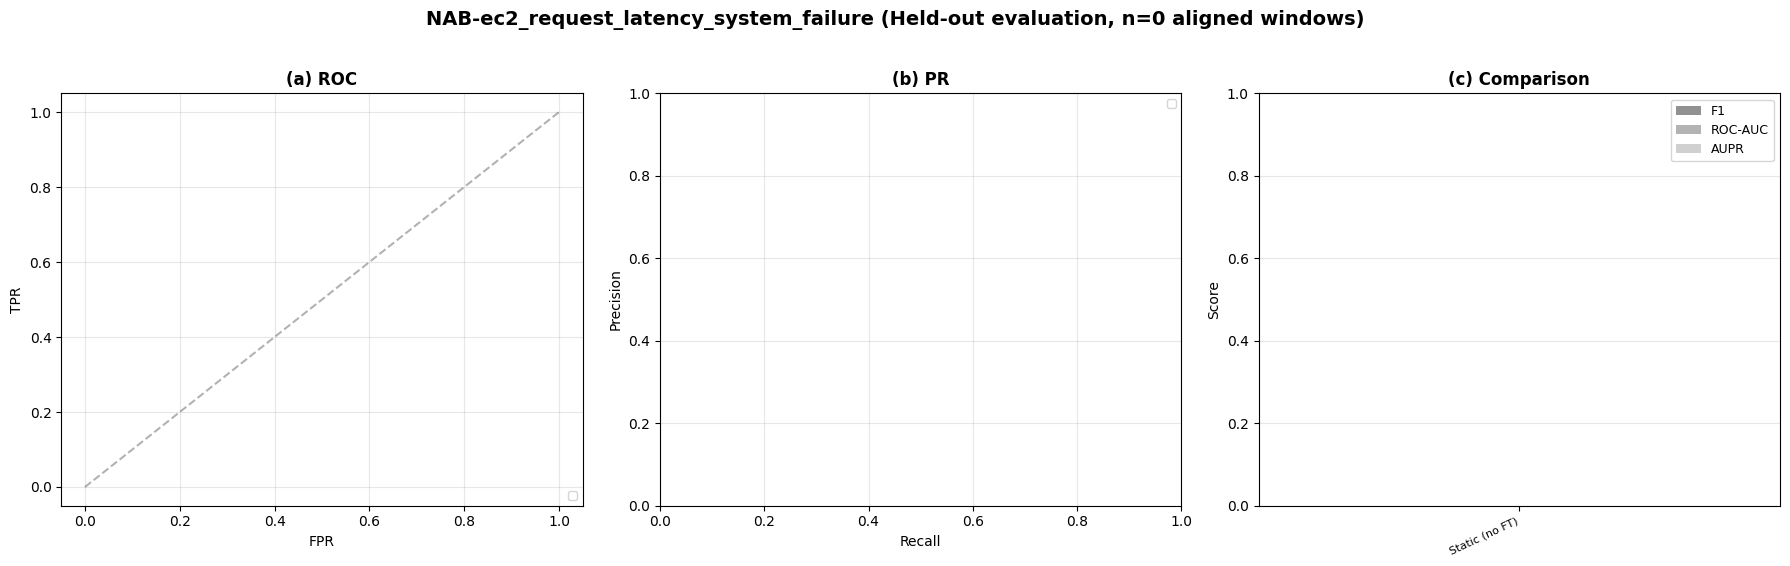

✓ Saved: evaluation_aligned.png


In [19]:
import json, glob, os, gc, warnings, typing, torch, logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import apache_beam as beam
from apache_beam.ml.inference.base import RunInference
from apache_beam.utils.timestamp import Timestamp
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score,
)
warnings.filterwarnings("ignore")
CONTEXT_LEN = 512

# Patch load_model for LoRA .pth — same as before.
_orig_load = DynamicTimesFmModelHandler.load_model
def _patched_load(self):
    if self._model_uri.endswith('.pth') and os.path.isfile(self._model_uri):
        logging.info(f"Loading base + LoRA from {self._model_uri}")
        # Always use the FULL window for re-inference, regardless of what
        # window the LoRA was trained on (small-data fallback may have used
        # ctx=256/horizon=64 etc.).
        base = timesfm.TimesFm(
            hparams=self._hparams,
            checkpoint=timesfm.TimesFmCheckpoint(
                huggingface_repo_id="google/timesfm-1.0-200m-pytorch"))
        inject_lora(base._model, rank=8, alpha=1.0)
        loaded = torch.load(self._model_uri, map_location='cpu')
        # v4 saves {'lora_state': ..., 'context_len': ..., 'horizon_len': ...}.
        # v3 saved the lora state dict directly. Handle both.
        if isinstance(loaded, dict) and 'lora_state' in loaded:
            state = loaded['lora_state']
            logging.info(f"  LoRA was trained with ctx={loaded.get('context_len')}, "
                         f"horizon={loaded.get('horizon_len')}")
        else:
            state = loaded
        base._model.load_state_dict(state, strict=False)
        self._model = base
        return base
    return _orig_load(self)
DynamicTimesFmModelHandler.load_model = _patched_load


# ── STEP 1: Find checkpoints ─────────────────────────────────────────────────
print("="*70)
print("  STEP 1: FIND LORA CHECKPOINTS")
print("="*70)

all_pth = glob.glob(os.path.join(os.getcwd(), '*.pth'))
print(f"\nAll .pth files ({len(all_pth)}):")
for f in sorted(all_pth, key=os.path.getmtime):
    print(f"  {os.path.basename(f)}  ({os.path.getsize(f)/1e6:.1f} MB)")

def find_ckpt(tag):
    tagged = [f for f in all_pth if f'_{tag}_' in os.path.basename(f).lower()]
    if tagged: return max(tagged, key=os.path.getmtime)
    if tag == 'gemini':
        others = [f for f in all_pth
                  if '_naive_' not in os.path.basename(f)
                  and '_claude_' not in os.path.basename(f)]
        if others: return max(others, key=os.path.getmtime)
    return None

gemini_ckpt = find_ckpt('gemini')
naive_ckpt  = find_ckpt('naive')
claude_ckpt = find_ckpt('claude')
print(f"\n  Gemini: {os.path.basename(gemini_ckpt) if gemini_ckpt else 'NOT FOUND'}")
print(f"  Naive:  {os.path.basename(naive_ckpt) if naive_ckpt else 'NOT FOUND'}")
print(f"  Claude: {os.path.basename(claude_ckpt) if claude_ckpt else 'NOT FOUND'}")


# ── STEP 2: Re-inference (FULL input_data so windows reach the held-out segment) ──
print(f"\n{'='*70}\n  STEP 2: RE-INFERENCE (full series)\n{'='*70}")

def run_reinference(ckpt, output_jsonl, label, base_model=False):
    """Run inference and dump windows to JSONL.
    base_model=True uses INITIAL_MODEL (no LoRA). Otherwise uses ckpt."""
    if not base_model and ckpt is None:
        print(f"\n  ⚠ Skipping {label}: no checkpoint")
        return
    gc.collect()
    if os.path.exists(output_jsonl):
        try: os.remove(output_jsonl)
        except PermissionError:
            output_jsonl = output_jsonl.replace('.jsonl', '_v2.jsonl')

    model_uri = INITIAL_MODEL if base_model else ckpt
    print(f"\n  {label}: {os.path.basename(str(model_uri))} → {output_jsonl}")
    handler = DynamicTimesFmModelHandler(model_uri=model_uri, hparams=hparams)
    with beam.Pipeline(options=options) as p:
        windowed = (
            p
            | f"{label}_Imp" >> PeriodicImpulse(data=input_data_eval, fire_interval=0.01)
            | f"{label}_Key" >> beam.WithKeys(lambda x: 0)
            | f"{label}_Win" >> beam.ParDo(
                OrderedSlidingWindowFn(window_size=WINDOW_SIZE, slide_interval=SLIDE_INTERVAL))
            | f"{label}_Gap" >> beam.ParDo(FillGapsFn(expected_interval=EXPECTED_INTERVAL))
            | f"{label}_NaN" >> beam.Filter(lambda b: 'NaN' not in b[1][2])
        )
        results = (windowed | f"{label}_Inf" >> RunInference(model_handler=handler))
        _ = (results | f"{label}_Out" >> beam.ParDo(WritePlotDataAndPassThrough(output_jsonl)))

    if os.path.exists(output_jsonl):
        with open(output_jsonl) as f:
            n = sum(1 for line in f if line.strip())
        print(f"    ✓ {n} windows")

FILES = {
    "Static (no FT)":  "plot_data_original.jsonl",
    "Naive LoRA FT":   f"plot_data_naive_{dataset_name}.jsonl",
    "Ours + Gemini":   "plot_data_finetuned.jsonl",
    "Ours + Claude":   f"plot_data_claude_{dataset_name}.jsonl",
}

# FIX: also re-run the BASE model on the FULL series, so "Static (no FT)" is
# evaluated on the same window coverage as the LoRA conditions. Previously
# plot_data_original.jsonl was produced by the training pipeline (cell 25)
# on input_data_train only, so its coverage didn't include the held-out
# segment that we now want to evaluate on.
run_reinference(None, FILES["Static (no FT)"], "RI_Base", base_model=True)
run_reinference(gemini_ckpt, FILES["Ours + Gemini"], "RI_Gemini")
run_reinference(naive_ckpt,  FILES["Naive LoRA FT"], "RI_Naive")
run_reinference(claude_ckpt, FILES["Ours + Claude"], "RI_Claude")


# ── STEP 3: Ground truth ─────────────────────────────────────────────────────
print(f"\n{'='*70}\n  STEP 3: GROUND TRUTH\n{'='*70}")

if ACTIVE_DATASET == "nyc_taxi":
    import kagglehub
    kpath = kagglehub.dataset_download("julienjta/nyc-taxi-traffic")
    csv_path = glob.glob(os.path.join(kpath, "**", "*.csv"), recursive=True)[0]
    df_gt = pd.read_csv(csv_path, parse_dates=["timestamp"]).sort_values("timestamp").reset_index(drop=True)
    gt_labels_full = np.zeros(len(df_gt), dtype=int)
    for s, e, name in [("2014-11-01 15:00","2014-11-02 06:00","NYC Marathon"),
                       ("2014-11-27 06:00","2014-11-28 12:00","Thanksgiving"),
                       ("2014-12-25 06:00","2014-12-26 12:00","Christmas"),
                       ("2015-01-01 06:00","2015-01-02 12:00","New Year's"),
                       ("2015-01-26 12:00","2015-01-28 00:00","Blizzard")]:
        m = (df_gt["timestamp"] >= pd.Timestamp(s)) & (df_gt["timestamp"] <= pd.Timestamp(e))
        gt_labels_full[m.values] = 1
        print(f"  {name}: {m.sum()} pts")
elif ACTIVE_DATASET.startswith("nab_"):
    import urllib.request
    nab_dir = os.path.expanduser("~/.cache/nab_data")
    label_path = os.path.join(nab_dir, "labels", "combined_labels.json")
    if not os.path.exists(label_path):
        url = "https://raw.githubusercontent.com/numenta/NAB/master/labels/combined_labels.json"
        os.makedirs(os.path.dirname(label_path), exist_ok=True)
        urllib.request.urlretrieve(url, label_path)
    with open(label_path) as f:
        all_labels = json.load(f)
    series_map = {
        "nab_temp":    "realKnownCause/ambient_temperature_system_failure",
        "nab_ec2":     "realKnownCause/ec2_request_latency_system_failure",
        "nab_machine": "realKnownCause/machine_temperature_system_failure",
        "nab_traffic": "realTraffic/occupancy_6005",
    }
    series_name = series_map.get(ACTIVE_DATASET, "")
    csv_path = os.path.join(nab_dir, "data", f"{series_name}.csv")
    df_gt = pd.read_csv(csv_path, parse_dates=["timestamp"]).sort_values("timestamp").reset_index(drop=True)
    gt_labels_full = np.zeros(len(df_gt), dtype=int)
    key = f"{series_name}.csv"
    if key in all_labels:
        for t in all_labels[key]:
            diffs = np.abs((df_gt["timestamp"] - pd.Timestamp(t)).dt.total_seconds())
            closest = diffs.idxmin()
            gt_labels_full[max(0, closest-5):min(len(df_gt), closest+6)] = 1
elif ACTIVE_DATASET.startswith("smd_"):
    import urllib.request
    machine = ACTIVE_DATASET.replace("smd_", "machine-").replace("_", "-")
    smd_dir = os.path.expanduser("~/.cache/smd_data")
    label_path = os.path.join(smd_dir, f"{machine}_labels.txt")
    if not os.path.exists(label_path):
        base = "https://raw.githubusercontent.com/NetManAIOps/OmniAnomaly/master/ServerMachineDataset"
        urllib.request.urlretrieve(f"{base}/test_label/{machine}.txt", label_path)
    test_labels = np.loadtxt(label_path, dtype=int)
    full_path = os.path.join(smd_dir, f"{machine}_full.txt")
    full_data = np.loadtxt(full_path, delimiter=",")
    n_train = len(full_data) - len(test_labels)
    gt_labels_full = np.concatenate([np.zeros(n_train, dtype=int), test_labels])
else:
    gt_labels_full = np.zeros(len(input_data), dtype=int)

gt_horizon = gt_labels_full[CONTEXT_LEN:]
print(f"  Anomalies in horizon (full): {gt_horizon.sum()}")
print(f"  Anomalies in held-out horizon "
      f"[{HELD_OUT_HORIZON_START}:): "
      f"{gt_horizon[HELD_OUT_HORIZON_START:].sum()}")


# ── STEP 4: WINDOW-ALIGNED METRICS ON HELD-OUT REGION ────────────────────────
print(f"\n{'='*70}\n  STEP 4: ALIGNED METRICS (held-out region only)\n{'='*70}")

def load_jsonl(path):
    rows = []
    if not os.path.exists(path): return rows
    with open(path) as f:
        for line in f:
            if line.strip(): rows.append(json.loads(line))
    return rows

for lb, pt in list(FILES.items()):
    if not os.path.exists(pt):
        v2 = pt.replace('.jsonl', '_v2.jsonl')
        if os.path.exists(v2): FILES[lb] = v2

conditions = {}
for label, path in FILES.items():
    rows = load_jsonl(path)
    if rows:
        conditions[label] = {r['start_ts_micros']: r for r in rows}
        print(f"  {label}: {len(rows)} windows")

if len(conditions) >= 2:
    common_ts = sorted(set.intersection(*(set(d.keys()) for d in conditions.values())))
    print(f"\n  Common windows across all conditions: {len(common_ts)}")
else:
    common_ts = []

def extract_aligned(condition_dict, common_ts):
    scores, flags = [], []
    for ts in common_ts:
        w = condition_dict[ts]
        act = np.array(w["actual_horizon_values"], dtype=float)
        prd = np.array(w["predicted_values"], dtype=float)
        q20 = np.array(w["q20_values"], dtype=float)
        q30 = np.array(w["q30_values"], dtype=float)
        q70 = np.array(w["q70_values"], dtype=float)
        q80 = np.array(w["q80_values"], dtype=float)
        Q1 = np.mean([q20, q30], axis=0)
        Q3 = np.mean([q70, q80], axis=0)
        IQR = np.where((Q3-Q1)==0, 1e-6, Q3-Q1)
        scores.extend((np.abs(act-prd)/IQR).tolist())
        fl = np.zeros(len(act), dtype=int)
        for a in w.get("anomalies", []):
            idx = a.get("index_in_window", -1) - CONTEXT_LEN
            if 0 <= idx < len(act): fl[idx] = 1
        flags.extend(fl.tolist())
    return np.array(scores), np.array(flags)

all_results, all_curves = [], {}
for label, cond_dict in conditions.items():
    sc, fl = extract_aligned(cond_dict, common_ts)
    n = min(len(sc), len(gt_horizon))
    # FIX: restrict every metric to the held-out region of the horizon.
    # HELD_OUT_HORIZON_START was computed in cell 20 from HELD_OUT_FRACTION.
    s = max(0, min(HELD_OUT_HORIZON_START, n))
    sc_h, fl_h, tr_h = sc[s:n], fl[s:n], gt_horizon[s:n]

    r = {"Condition": label}
    if fl_h.sum() > 0 and tr_h.sum() > 0:
        r["Precision"] = precision_score(tr_h, fl_h, zero_division=0)
        r["Recall"]    = recall_score(tr_h, fl_h, zero_division=0)
        r["F1"]        = f1_score(tr_h, fl_h, zero_division=0)
    else:
        r["Precision"] = r["Recall"] = r["F1"] = 0.0
    r["ROC-AUC"]   = roc_auc_score(tr_h, sc_h) if len(set(tr_h)) >= 2 else float("nan")
    r["AUPR"]      = average_precision_score(tr_h, sc_h) if len(set(tr_h)) >= 2 else float("nan")
    all_results.append(r)
    all_curves[label] = (sc_h, tr_h)
    print(f"\n  {label}: held-out pts={len(tr_h)}, anomalies={int(tr_h.sum())}")
    print(f"    P={r['Precision']:.4f} R={r['Recall']:.4f} F1={r['F1']:.4f} "
          f"AUC={r['ROC-AUC']:.4f} AUPR={r['AUPR']:.4f}")


# ── STEP 5: Table + figures ──────────────────────────────────────────────────
if all_results:
    df_r = pd.DataFrame(all_results)
    df_d = df_r[["Condition","Precision","Recall","F1","ROC-AUC","AUPR"]].copy()
    for c in ["Precision","Recall","F1","ROC-AUC","AUPR"]:
        df_d[c] = df_d[c].apply(lambda x: f"{x:.4f}" if not np.isnan(x) else "N/A")
    print(f"\n\n{'='*70}\n  COMPARISON TABLE — {dataset_name}  (held-out only)\n{'='*70}")
    print(df_d.to_string(index=False))
    print(f"{'='*70}")

COLORS = {"Static (no FT)":"#8B8B8B","Naive LoRA FT":"#E07A5F",
          "Ours + Gemini":"#3D85C6","Ours + Claude":"#81B29A"}

if all_curves:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
    fig.suptitle(
        f"{dataset_name} (Held-out evaluation, n={len(common_ts)} aligned windows)",
        fontsize=14, fontweight="bold", y=1.02)
    ax = axes[0]
    for lb, (sc, tr) in all_curves.items():
        if len(set(tr))<2: continue
        fpr,tpr,_ = roc_curve(tr, sc)
        ax.plot(fpr, tpr, label=f"{lb} ({roc_auc_score(tr,sc):.3f})",
                color=COLORS.get(lb,"#333"), linewidth=2)
    ax.plot([0,1],[0,1],"k--",alpha=0.3)
    ax.set_xlabel("FPR"); ax.set_ylabel("TPR"); ax.set_title("(a) ROC", fontweight="bold")
    ax.legend(fontsize=8,loc="lower right"); ax.grid(True,alpha=0.3)

    ax = axes[1]
    for lb, (sc, tr) in all_curves.items():
        if len(set(tr))<2: continue
        pr,rc,_ = precision_recall_curve(tr, sc)
        ax.plot(rc, pr, label=f"{lb} ({average_precision_score(tr,sc):.3f})",
                color=COLORS.get(lb,"#333"), linewidth=2)
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision"); ax.set_title("(b) PR", fontweight="bold")
    ax.legend(fontsize=8); ax.grid(True,alpha=0.3)

    ax = axes[2]
    df_b = pd.DataFrame(all_results)
    conds = df_b["Condition"].tolist(); x = np.arange(len(conds)); w=0.22
    for off,met,al in [(-w,"F1",0.95),(0,"ROC-AUC",0.65),(w,"AUPR",0.4)]:
        bars = ax.bar(x+off, df_b[met].fillna(0).values, w, label=met,
                     color=[COLORS.get(c,"#333") for c in conds], alpha=al)
        for b in bars:
            h=b.get_height()
            if h>0.01: ax.text(b.get_x()+b.get_width()/2,h+0.015,f"{h:.2f}",ha="center",fontsize=7)
    ax.set_xticks(x); ax.set_xticklabels(conds,rotation=25,ha="right",fontsize=8)
    ax.set_ylabel("Score"); ax.set_title("(c) Comparison",fontweight="bold")
    ax.legend(fontsize=9); ax.set_ylim([0,1]); ax.grid(True,alpha=0.3,axis="y")
    plt.tight_layout()
    plt.savefig("evaluation_aligned.png", dpi=200, bbox_inches="tight")
    plt.show()
    print("✓ Saved: evaluation_aligned.png")


---
## Step 6 — RLAIF Stage 2 (decision module)

Trains a small RLAIF decision module on top of the LoRA-fine-tuned model's anomaly scores, then evaluates it on a held-out tune/test split (no threshold leakage).

**Depends on** the JSONL files produced in Step 5. If you skipped Step 5, this cell prints a warning and exits cleanly.

In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# DEPENDENCY GUARD: this cell evaluates the post-fine-tune model, so it needs
# the JSONL files produced by Cell 39 (RE-INFERENCE + EVALUATION). If you ran
# the notebook top-to-bottom, run Cell 39 BEFORE this cell.
# ─────────────────────────────────────────────────────────────────────────────
import os as _os
if not (_os.path.exists('plot_data_finetuned.jsonl')
        and _os.path.exists('plot_data_original.jsonl')):
    print("Required JSONLs not found — skipping RLAIF Stage 2.")
    print("Required:")
    print("  plot_data_original.jsonl   (base TimesFM on full series)")
    print("  plot_data_finetuned.jsonl  (Gemini LoRA on full series)")
    print("Run Cell 39 (RE-INFERENCE + EVALUATION) first; it produces both.")
else:
    # =========================================================================
    #  STAGE 2 — RLAIF DECISION MODULE  (held-out evaluation)
    # =========================================================================
    import json, glob
    import numpy as np
    import pandas as pd
    from scipy import stats
    from sklearn.metrics import f1_score, precision_score, recall_score

    def load_jsonl(path):
        rows = []
        with open(path) as f:
            for line in f:
                if line.strip():
                    rows.append(json.loads(line))
        rows.sort(key=lambda x: x.get('start_ts_micros', 0))
        return rows

    def flatten_windows(windows):
        pred, q20, q30, q70, q80, actual, anomalies = [], [], [], [], [], [], []
        for w in windows:
            pred.extend(w.get('predicted_values', []))
            q20.extend(w.get('q20_values', []))
            q30.extend(w.get('q30_values', []))
            q70.extend(w.get('q70_values', []))
            q80.extend(w.get('q80_values', []))
            actual.extend(w.get('actual_horizon_values', []))
            anomalies.extend(w.get('anomalies', []))
        return (np.array(pred), np.array(q20), np.array(q30),
                np.array(q70), np.array(q80), np.array(actual), anomalies)

    def metrics(pred_flags, true_flags, tag=''):
        p = precision_score(true_flags, pred_flags, zero_division=0)
        r = recall_score(true_flags, pred_flags, zero_division=0)
        f = f1_score(true_flags, pred_flags, zero_division=0)
        print(f"  [{tag}]  F1={f:.4f}  Precision={p:.4f}  Recall={r:.4f}")
        return dict(tag=tag, f1=f, precision=p, recall=r)

    # FIX: restrict the IQR-band F1 to the held-out region.
    def compute_baseline_f1(windows, gt_horizon, held_start, tag=""):
        if not windows:
            print(f"  [{tag}]  no windows — F1=0.0000")
            return {"f1": 0.0, "precision": 0.0, "recall": 0.0}
        flags = []
        for w in windows:
            act = np.array(w["actual_horizon_values"], dtype=float)
            q20 = np.array(w["q20_values"], dtype=float)
            q80 = np.array(w["q80_values"], dtype=float)
            outside = (act < q20) | (act > q80)
            flags.extend(outside.astype(int).tolist())
        flags = np.array(flags)
        m = min(len(flags), len(gt_horizon))
        s = max(0, min(held_start, m))
        flags = flags[s:m]
        truth = gt_horizon[s:m]
        if flags.sum() == 0 or truth.sum() == 0:
            print(f"  [{tag}]  no positives in held-out — F1=0.0000  ({len(truth)} pts)")
            return {"f1": 0.0, "precision": 0.0, "recall": 0.0}
        p = precision_score(truth, flags, zero_division=0)
        r = recall_score(truth, flags, zero_division=0)
        f = f1_score(truth, flags, zero_division=0)
        print(f"  [{tag}]  F1={f:.4f}  Precision={p:.4f}  Recall={r:.4f}  ({len(truth)} held-out pts)")
        return {"f1": f, "precision": p, "recall": r}

    CONTEXT_LEN = 512
    orig_windows = load_jsonl('plot_data_original.jsonl')
    fine_windows = load_jsonl('plot_data_finetuned.jsonl')
    print(f"Loaded {len(orig_windows)} original, {len(fine_windows)} finetuned windows")

    (pred_post, q20_post, q30_post, q70_post, q80_post,
     actual_post, _) = flatten_windows(fine_windows)
    n = len(actual_post)

    # Ground-truth labels — same logic as cell 39, kept in-cell to avoid global
    # state coupling between the two cells.
    if ACTIVE_DATASET == "nyc_taxi":
        import kagglehub
        kpath = kagglehub.dataset_download("julienjta/nyc-taxi-traffic")
        csv_path = glob.glob(os.path.join(kpath, "**", "*.csv"), recursive=True)[0]
        df_gt = pd.read_csv(csv_path, parse_dates=["timestamp"]).sort_values("timestamp").reset_index(drop=True)
        gt_labels_full = np.zeros(len(df_gt), dtype=int)
        for s, e in [("2014-11-01 15:00","2014-11-02 06:00"),
                     ("2014-11-27 06:00","2014-11-28 12:00"),
                     ("2014-12-25 06:00","2014-12-26 12:00"),
                     ("2015-01-01 06:00","2015-01-02 12:00"),
                     ("2015-01-26 12:00","2015-01-28 00:00")]:
            mask = (df_gt["timestamp"] >= pd.Timestamp(s)) & (df_gt["timestamp"] <= pd.Timestamp(e))
            gt_labels_full[mask.values] = 1
        true_lbl = gt_labels_full[CONTEXT_LEN:CONTEXT_LEN + n]
    elif ACTIVE_DATASET.startswith("nab_"):
        import urllib.request
        nab_dir = os.path.expanduser("~/.cache/nab_data")
        label_path = os.path.join(nab_dir, "labels", "combined_labels.json")
        if not os.path.exists(label_path):
            url = "https://raw.githubusercontent.com/numenta/NAB/master/labels/combined_labels.json"
            os.makedirs(os.path.dirname(label_path), exist_ok=True)
            urllib.request.urlretrieve(url, label_path)
        with open(label_path) as f:
            all_labels = json.load(f)
        series_map = {
            "nab_temp":    "realKnownCause/ambient_temperature_system_failure",
            "nab_ec2":     "realKnownCause/ec2_request_latency_system_failure",
            "nab_machine": "realKnownCause/machine_temperature_system_failure",
            "nab_traffic": "realTraffic/occupancy_6005",
        }
        series_name = series_map.get(ACTIVE_DATASET, "")
        csv_path = os.path.join(nab_dir, "data", f"{series_name}.csv")
        df_gt = pd.read_csv(csv_path, parse_dates=["timestamp"]).sort_values("timestamp").reset_index(drop=True)
        gt_labels_full = np.zeros(len(df_gt), dtype=int)
        key = f"{series_name}.csv"
        if key in all_labels:
            for t in all_labels[key]:
                diffs = np.abs((df_gt["timestamp"] - pd.Timestamp(t)).dt.total_seconds())
                closest = diffs.idxmin()
                gt_labels_full[max(0, closest-5):min(len(df_gt), closest+6)] = 1
        true_lbl = gt_labels_full[CONTEXT_LEN:CONTEXT_LEN + n]
    elif ACTIVE_DATASET.startswith("smd_"):
        import urllib.request
        machine = ACTIVE_DATASET.replace("smd_", "machine-").replace("_", "-")
        smd_dir = os.path.expanduser("~/.cache/smd_data")
        label_path = os.path.join(smd_dir, f"{machine}_labels.txt")
        if not os.path.exists(label_path):
            base = "https://raw.githubusercontent.com/NetManAIOps/OmniAnomaly/master/ServerMachineDataset"
            urllib.request.urlretrieve(f"{base}/test_label/{machine}.txt", label_path)
        test_labels = np.loadtxt(label_path, dtype=int)
        full_path = os.path.join(smd_dir, f"{machine}_full.txt")
        full_data = np.loadtxt(full_path, delimiter=",")
        n_train = len(full_data) - len(test_labels)
        gt_labels_full = np.concatenate([np.zeros(n_train, dtype=int), test_labels])
        true_lbl = gt_labels_full[CONTEXT_LEN:CONTEXT_LEN + n]
    else:
        print(f"  No ground-truth labels for {ACTIVE_DATASET}, using zeros")
        true_lbl = np.zeros(n, dtype=int)

    print(f"Horizon points: {n}")
    print(f"Held-out range begins at horizon idx {HELD_OUT_HORIZON_START}")
    print(f"  Anomalies (full horizon):    {true_lbl.sum()}")
    print(f"  Anomalies (held-out only):   {true_lbl[HELD_OUT_HORIZON_START:].sum()}")

    print("\nBaseline F1 (IQR-band rule, held-out region):")
    pre_m  = compute_baseline_f1(orig_windows, true_lbl, HELD_OUT_HORIZON_START,
                                 tag="Pre-LoRA  (Static)")
    post_m = compute_baseline_f1(fine_windows, true_lbl, HELD_OUT_HORIZON_START,
                                 tag="Post-LoRA (Gemini)")

    # ── Feature extraction ───────────────────────────────────────────────────
    def extract_features(window_vals, forecast_val, iqr_width):
        w = np.asarray(window_vals, dtype=float)
        w = w[~np.isnan(w)]
        if len(w) == 0:
            return np.zeros(12, dtype=np.float32)
        sigma    = max(iqr_width / 1.35, 1e-6)
        residual = abs(float(w[-1]) - float(forecast_val))
        mean_w   = float(w.mean())
        std_w    = float(w.std()) + 1e-6
        z_score  = residual / sigma
        spike    = abs(w[-1] - mean_w) / std_w
        q1, q3   = np.percentile(w, 25), np.percentile(w, 75)
        iqr_dev  = abs(w[-1] - q3) / (q3 - q1 + 1e-6)
        diffs     = np.diff(w) if len(w) > 1 else np.array([0.0])
        slope     = abs(float(diffs[-1]))
        max_jump  = float(abs(diffs).max())
        curvature = float(abs(np.diff(diffs)).mean()) if len(diffs) > 1 else 0.0
        autocorr = float(np.corrcoef(w[:-1], w[1:])[0, 1]) if len(w) > 2 else 0.0
        if np.isnan(autocorr):
            autocorr = 0.0
        skew = float(stats.skew(w))     if len(w) > 3 else 0.0
        kurt = float(stats.kurtosis(w)) if len(w) > 3 else 0.0
        half = max(1, len(w) // 2)
        if len(w[half:]) > 0 and len(w[:half]) > 0:
            shift = abs(float(w[half:].mean()) - float(w[:half].mean())) / sigma
        else:
            shift = 0.0
        completeness = float(np.clip(len(w) / 128, 0, 1))
        return np.array([
            np.tanh(z_score),    np.tanh(spike),       np.tanh(iqr_dev),
            np.tanh(slope),      np.tanh(max_jump),    np.tanh(curvature),
            np.clip(autocorr, -1, 1), np.tanh(skew),  np.tanh(kurt / 6),
            np.tanh(residual / sigma), completeness,   np.tanh(shift),
        ], dtype=np.float32)

    # ── Preference dataset (built from training-region anomalies) ────────────
    KEEP_SCORE_THRESHOLD = 2.0
    feats_keep, feats_remove = [], []
    for w in fine_windows:
        preds    = w.get('predicted_values', [])
        q20v     = w.get('q20_values', [])
        q80v     = w.get('q80_values', [])
        actual_h = w.get('actual_horizon_values', [])
        anomalies = w.get('anomalies', [])
        for a in anomalies:
            if 'index_in_window' not in a:
                continue
            h_idx = int(a['index_in_window']) - CONTEXT_LEN
            if not (0 <= h_idx < len(preds)):
                continue
            forecast_v = float(preds[h_idx])
            q20_v      = float(q20v[h_idx]) if h_idx < len(q20v) else forecast_v
            q80_v      = float(q80v[h_idx]) if h_idx < len(q80v) else forecast_v
            iqr_w      = abs(q80_v - q20_v) + 1e-6
            ctx_start  = max(0, h_idx - 48)
            window_sl  = np.array(actual_h[ctx_start: h_idx + 1])
            feat       = extract_features(window_sl, forecast_v, iqr_w)
            score      = float(a.get('outlier_score', 1.0))
            if score >= KEEP_SCORE_THRESHOLD:
                feats_keep.append(feat)
            else:
                feats_remove.append(feat)

    feats_keep   = np.array(feats_keep)   if feats_keep   else np.empty((0, 12))
    feats_remove = np.array(feats_remove) if feats_remove else np.empty((0, 12))
    print(f"Preference dataset — KEEP: {len(feats_keep)}  REMOVE: {len(feats_remove)}")

    feats_keep_balanced = feats_keep
    if len(feats_keep) > 0 and len(feats_remove) > 0:
        repeat_times = max(1, len(feats_remove) // len(feats_keep))
        feats_keep_balanced = np.tile(feats_keep, (repeat_times, 1))
        feats_keep_balanced += np.random.normal(0, 0.01, feats_keep_balanced.shape).astype(np.float32)
        print(f"  Balanced: KEEP={len(feats_keep_balanced)}  REMOVE={len(feats_remove)}")

    all_X = (np.vstack([feats_keep_balanced, feats_remove])
             if len(feats_keep_balanced) + len(feats_remove) > 0
             else np.empty((0, 12)))
    all_y = np.array([1]*len(feats_keep_balanced) + [0]*len(feats_remove), dtype=int)


    # ── RLAIF Decision Module ────────────────────────────────────────────────
    class DecisionModule:
        def __init__(self, feat_dim=12, hidden=48, lr=0.008):
            rng      = np.random.default_rng(42)
            self.W1  = rng.normal(0, np.sqrt(2/feat_dim), (feat_dim, hidden)).astype(np.float32)
            self.b1  = np.zeros(hidden, dtype=np.float32)
            self.W2  = rng.normal(0, np.sqrt(2/hidden),   (hidden, 1)).astype(np.float32)
            self.b2  = np.zeros(1, dtype=np.float32)
            self.lr  = lr
            self.history = {'loss': [], 'f1': []}

        def _sigmoid(self, x):
            return 1.0 / (1.0 + np.exp(-np.clip(x, -30, 30)))

        def forward(self, x):
            h = np.tanh(x @ self.W1 + self.b1)
            return float(self._sigmoid((h @ self.W2 + self.b2)[0]))

        def prob(self, X):
            return np.array([self.forward(x) for x in X])

        def predict(self, X, thr=0.5):
            return (self.prob(X) >= thr).astype(int)

        def _step(self, x, action, advantage):
            h    = np.tanh(x @ self.W1 + self.b1)
            p    = float(self._sigmoid((h @ self.W2 + self.b2)[0]))
            dp   = (-advantage * (1 - p)) if action == 1 else (advantage * p)
            dpr  = dp * p * (1 - p)
            clip = 1.0
            dW2  = np.outer(h, [dpr])
            dh   = dpr * self.W2[:, 0] * (1 - h**2)
            dW1  = np.outer(x, dh)
            self.W2 -= self.lr * np.clip(dW2, -clip, clip)
            self.b2 -= self.lr * np.array([np.clip(dpr, -clip, clip)])
            self.W1 -= self.lr * np.clip(dW1, -clip, clip)
            self.b1 -= self.lr * np.clip(dh,  -clip, clip)

        def train_rlaif(self, feats_keep, feats_remove, epochs=60):
            if len(feats_keep) == 0 or len(feats_remove) == 0:
                print("  Not enough KEEP/REMOVE pairs. Skipping RLAIF training.")
                return
            X_all    = np.vstack([feats_keep, feats_remove])
            y_all    = np.r_[np.ones(len(feats_keep)), np.zeros(len(feats_remove))]
            n_pairs  = min(len(feats_keep), len(feats_remove), 16)
            baseline = 0.0
            for ep in range(1, epochs + 1):
                ik = np.random.choice(len(feats_keep),   n_pairs, replace=True)
                ir = np.random.choice(len(feats_remove), n_pairs, replace=True)
                ep_loss = 0.0
                for i, j in zip(ik, ir):
                    pk   = self.forward(feats_keep[i])
                    pr   = self.forward(feats_remove[j])
                    diff = np.log(pk + 1e-8) - np.log(pr + 1e-8)
                    ep_loss += -np.log(self._sigmoid(0.5 * diff) + 1e-8)
                    self._step(feats_keep[i],   1, 0.5)
                    self._step(feats_remove[j], 0, 0.5)
                rewards = []
                for i in np.random.permutation(len(X_all)):
                    a = int(self.forward(X_all[i]) >= 0.5)
                    r = 1.0 if a == int(y_all[i]) else -1.0
                    rewards.append(r)
                    self._step(X_all[i], a, (r - baseline) * 0.15)
                baseline = 0.95 * baseline + 0.05 * float(np.mean(rewards))
                f1_ep = f1_score(y_all, self.predict(X_all), zero_division=0)
                self.history['loss'].append(ep_loss / max(n_pairs, 1))
                self.history['f1'].append(f1_ep)
            print(f"  RLAIF training done. Final F1 on pref dataset = {self.history['f1'][-1]:.4f}")

    print("\nTraining RLAIF Decision Module …")
    dm = DecisionModule(feat_dim=12, hidden=48, lr=0.008)
    dm.train_rlaif(feats_keep_balanced, feats_remove, epochs=60)

    # ── Build held-out ground-truth eval set ─────────────────────────────────
    # FIX: positives + negatives are sampled ONLY from the held-out region.
    held_mask  = np.arange(len(true_lbl)) >= HELD_OUT_HORIZON_START
    pos_idx    = np.where((true_lbl == 1) & held_mask)[0]
    neg_idx    = np.where((true_lbl == 0) & held_mask)[0]

    if len(pos_idx) > 0 and len(actual_post) >= n:
        rng = np.random.default_rng(42)
        n_neg = min(len(pos_idx), len(neg_idx))
        neg_sample = rng.choice(neg_idx, n_neg, replace=False) if n_neg > 0 else np.array([], dtype=int)

        def feats_for(indices):
            out = []
            for h_idx in indices:
                ctx_start = max(0, h_idx - 48)
                window_sl = actual_post[ctx_start: h_idx + 1]
                if h_idx < len(pred_post) and h_idx < len(q20_post):
                    iqr_w = abs(float(q80_post[h_idx]) - float(q20_post[h_idx])) + 1e-6
                    f_vec = extract_features(window_sl, float(pred_post[h_idx]), iqr_w)
                else:
                    f_vec = np.zeros(12, dtype=np.float32)
                out.append(f_vec)
            return np.array(out) if out else np.empty((0, 12))

        gt_feats  = feats_for(pos_idx)
        neg_feats = feats_for(neg_sample)

        eval_X = np.vstack([gt_feats, neg_feats])
        eval_y = np.r_[np.ones(len(gt_feats)), np.zeros(len(neg_feats))].astype(int)

        # ── FIX: tune/test split for threshold selection (was leaked before)
        n_eval = len(eval_X)
        perm  = rng.permutation(n_eval)
        n_tune = int(n_eval * 0.7)
        tune_idx, test_idx = perm[:n_tune], perm[n_tune:]
        thr_range = np.linspace(0.1, 0.9, 50)

        probs_tune = np.nan_to_num(dm.prob(eval_X[tune_idx]), nan=0.5)
        probs_test = np.nan_to_num(dm.prob(eval_X[test_idx]), nan=0.5)

        if len(tune_idx) > 0 and eval_y[tune_idx].sum() > 0:
            tune_f1 = [f1_score(eval_y[tune_idx],
                                (probs_tune >= t).astype(int), zero_division=0)
                       for t in thr_range]
            best_thr = thr_range[int(np.argmax(tune_f1))]
        else:
            best_thr = 0.5
        print(f"  τ chosen on TUNE split: {best_thr:.2f}  (F1_tune={max(tune_f1):.4f})")

        s2_m    = metrics((probs_test >= 0.45).astype(int), eval_y[test_idx],
                          'RLAIF τ=0.45 (test)')
        s2_best = metrics((probs_test >= best_thr).astype(int), eval_y[test_idx],
                          f'RLAIF τ*={best_thr:.2f} (test, no leakage)')
    else:
        print("  Not enough held-out anomalies for ground-truth RLAIF evaluation.")
        s2_m    = dict(f1=0.0, precision=0.0, recall=0.0, tag='RLAIF')
        s2_best = s2_m

    print(f"\n── Final Results (held-out region) ───────────────────────")
    print(f"  Pre-LoRA  F1 = {pre_m['f1']:.4f}  (P={pre_m['precision']:.4f}  R={pre_m['recall']:.4f})")
    print(f"  Post-LoRA F1 = {post_m['f1']:.4f}  (P={post_m['precision']:.4f}  R={post_m['recall']:.4f})  (Δ={post_m['f1']-pre_m['f1']:+.4f})")
    print(f"  RLAIF     F1 = {s2_best['f1']:.4f}  (P={s2_best['precision']:.4f}  R={s2_best['recall']:.4f})  (Δ={s2_best['f1']-post_m['f1']:+.4f})")
    print(f"  Total ΔF1    = {s2_best['f1']-pre_m['f1']:+.4f}")
    print(f"──────────────────────────────────────────────────────────")


Required JSONLs not found — skipping RLAIF Stage 2.
Required:
  plot_data_original.jsonl   (base TimesFM on full series)
  plot_data_finetuned.jsonl  (Gemini LoRA on full series)
Run Cell 39 (RE-INFERENCE + EVALUATION) first; it produces both.


---
## Step 7 (optional) — Plot original-vs-finetuned forecasts

Visual sanity check. Shows the base model's forecasts and the Gemini-LoRA's forecasts side by side.

Total points to plot: 3328
Total anomalies: 50


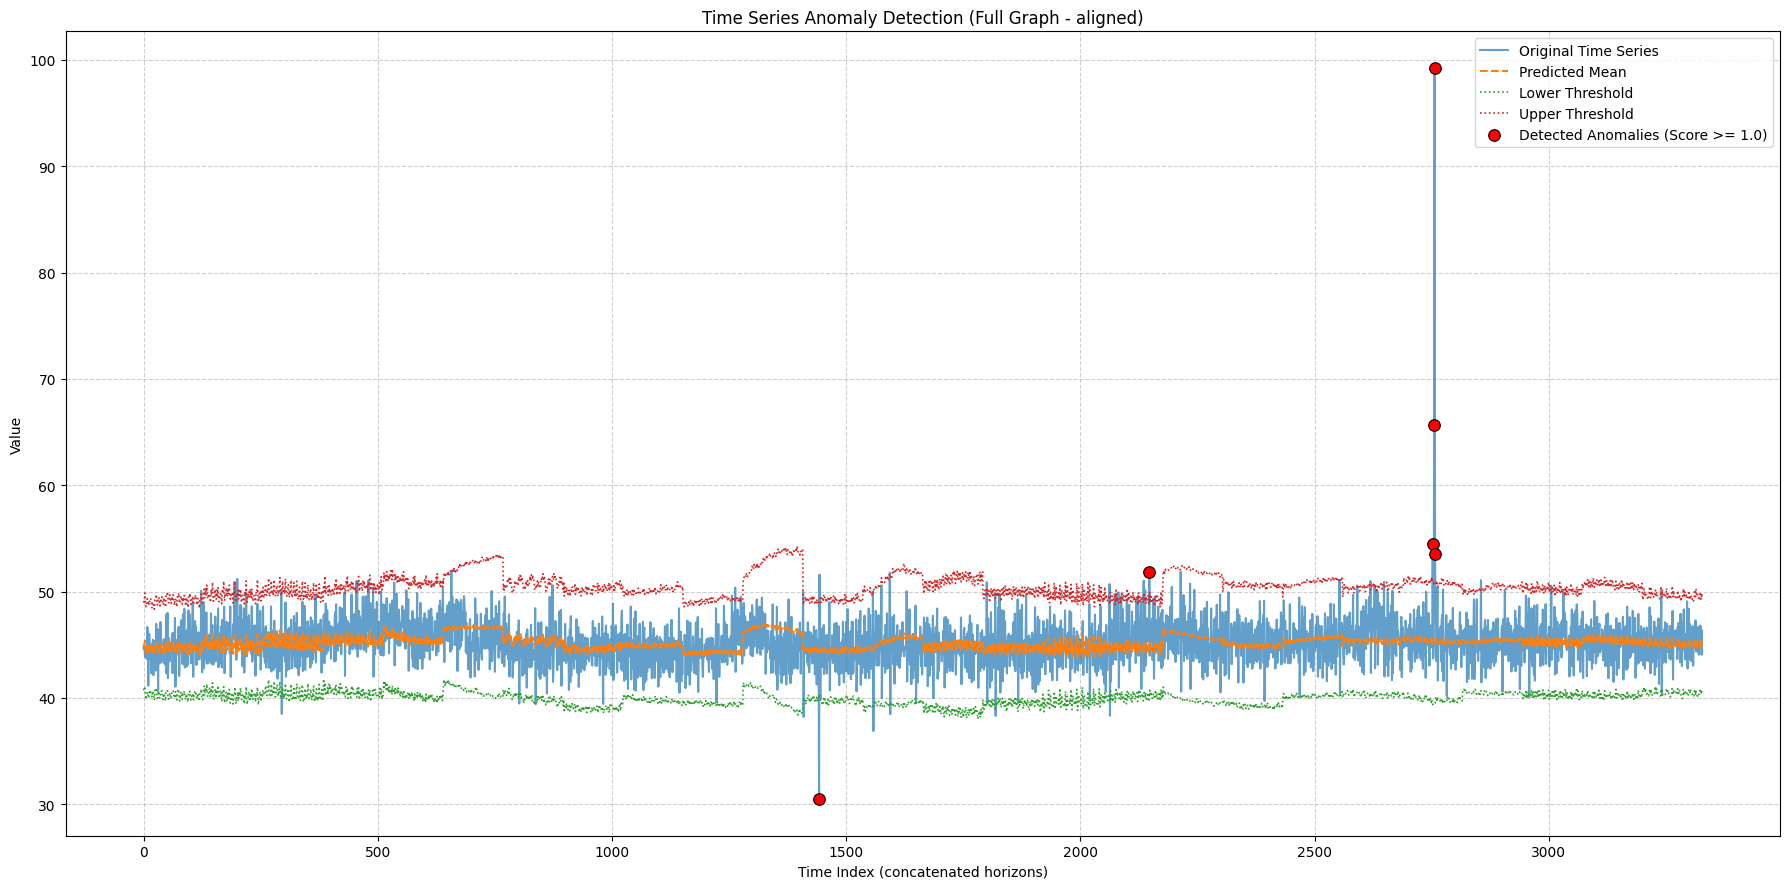

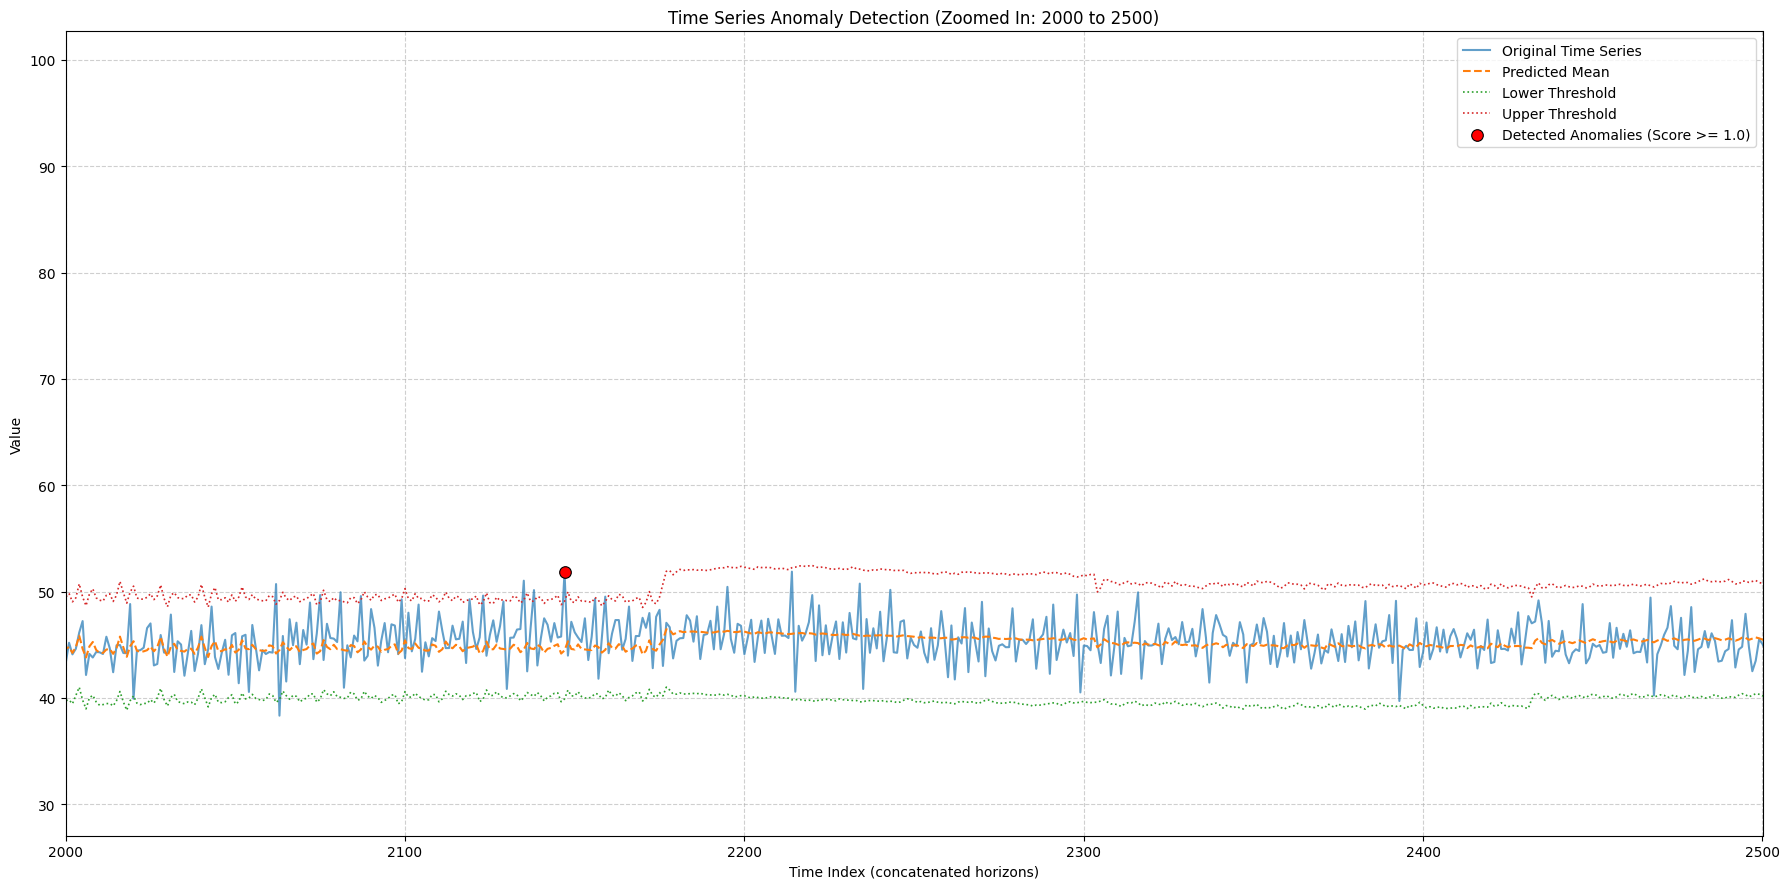

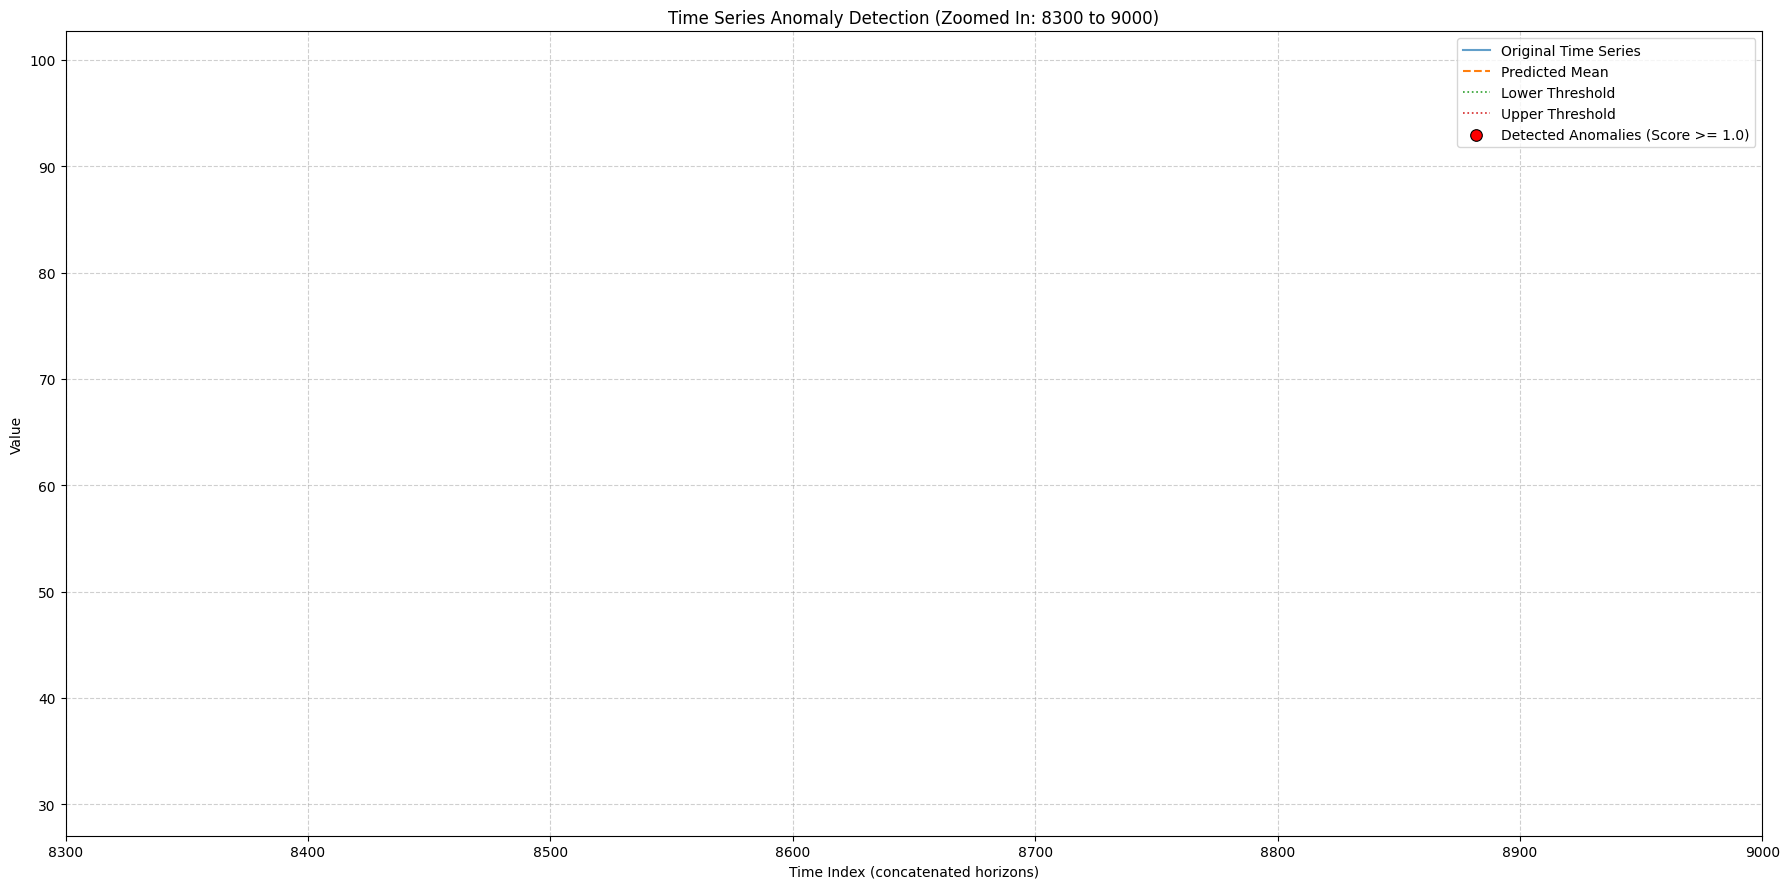

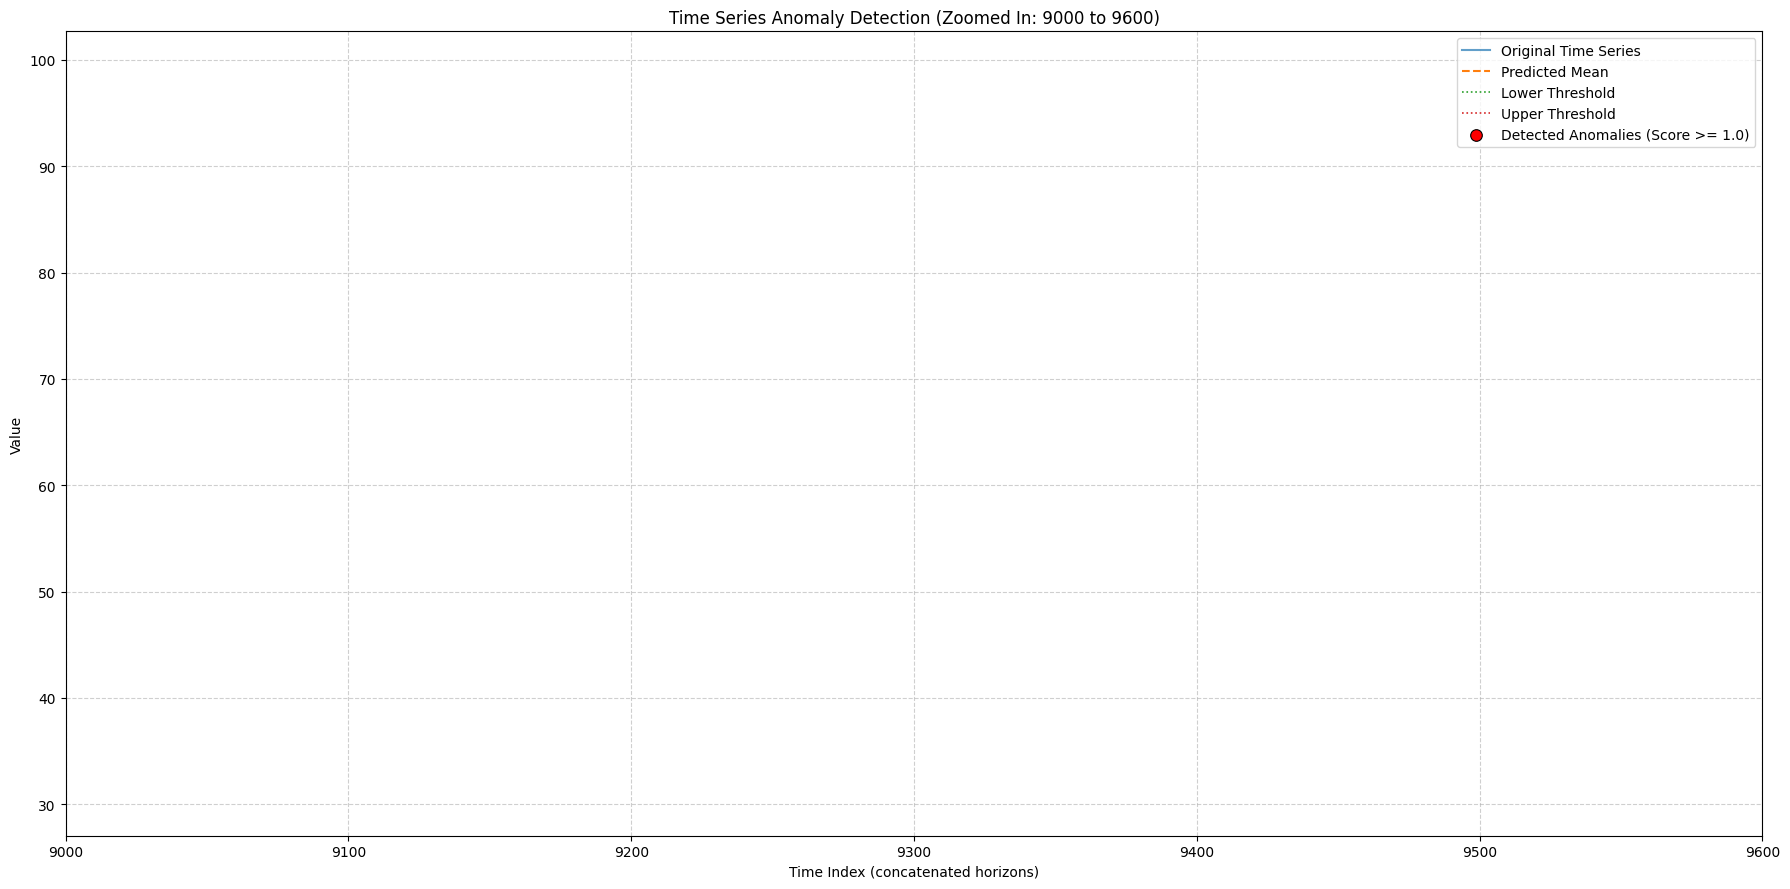

In [21]:
import json
import numpy as np
import matplotlib.pyplot as plt

CONTEXT_LEN = 512
HORIZON_LEN = 128


def plot_anomalies_and_forecast(
    actual_horizon_values,          # blue line (real values of horizon, concatenated)
    predicted_values,               # green line (pred mean, concatenated)
    q20_values,
    q30_values,
    q70_values,
    q80_values,
    global_anomalies,               # list of (global_x, actual_value, outlier_score)
    title_suffix="",
    x_lims=None,
    min_outlier_score_for_plot=0,
):
    # filter anomalies by score
    filtered = [(x, y, s) for (x, y, s) in global_anomalies if s >= min_outlier_score_for_plot]
    anomaly_x = [x for (x, _, _) in filtered]
    anomaly_y = [y for (_, y, _) in filtered]

    # thresholds from quantiles
    Q1 = np.nanmean([q20_values, q30_values], axis=0)
    Q3 = np.nanmean([q70_values, q80_values], axis=0)
    IQR = Q3 - Q1
    upper_thresh = Q3 + 1.5 * IQR
    lower_thresh = Q1 - 1.5 * IQR

    plt.figure(figsize=(18, 9))
    plt.plot(actual_horizon_values, label="Original Time Series", alpha=0.7, linewidth=1.5)
    plt.plot(predicted_values, label="Predicted Mean", linestyle="--", linewidth=1.5)
    plt.plot(lower_thresh, label="Lower Threshold", linestyle=":", linewidth=1.2)
    plt.plot(upper_thresh, label="Upper Threshold", linestyle=":", linewidth=1.2)

    if len(anomaly_x) > 0:
        plt.scatter(
            anomaly_x, anomaly_y,
            color="red", s=70, zorder=5,
            label=f"Detected Anomalies (Score >= {min_outlier_score_for_plot:.1f})",
            marker="o", edgecolors="black", linewidths=0.8
        )

    plt.title(f"Time Series Anomaly Detection {title_suffix}")
    plt.xlabel("Time Index (concatenated horizons)")
    plt.ylabel("Value")

    if x_lims is not None:
        plt.xlim(x_lims[0], x_lims[1])

    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()
    plt.close()


# ==============================
# MAIN: Read JSONL + Build Arrays
# ==============================

all_window_data = []
try:
    with open("plot_data_original.jsonl", "r") as f:
        for line in f:
            if line.strip():
                all_window_data.append(json.loads(line))
except FileNotFoundError:
    raise FileNotFoundError("plot_data_original.jsonl not found. Put it in the same folder as your notebook.")

# sort by window start time
all_window_data.sort(key=lambda x: x.get("start_ts_micros", 0))

# Collect concatenated series
all_predicted_values = []
all_q20_values = []
all_q30_values = []
all_q70_values = []
all_q80_values = []
all_actual_horizon_values = []

# This will store anomalies aligned to the concatenated horizon index:
# (global_x_index, actual_value, outlier_score)
global_anomalies = []

# We will append horizon-by-horizon; this offset tracks the global index
horizon_offset = 0

for window_data in all_window_data:
    preds = window_data.get("predicted_values", [])
    q20 = window_data.get("q20_values", [])
    q30 = window_data.get("q30_values", [])
    q70 = window_data.get("q70_values", [])
    q80 = window_data.get("q80_values", [])
    actuals = window_data.get("actual_horizon_values", [])

    # Append sequences
    all_predicted_values.extend(preds)
    all_q20_values.extend(q20)
    all_q30_values.extend(q30)
    all_q70_values.extend(q70)
    all_q80_values.extend(q80)
    all_actual_horizon_values.extend(actuals)

    # Align anomalies properly
    anomalies = window_data.get("anomalies", [])
    for a in anomalies:
        # We rely on index_in_window, NOT timestamp
        if "index_in_window" not in a:
            continue

        local_index = int(a["index_in_window"]) - CONTEXT_LEN  # 0..HORIZON_LEN-1
        if local_index < 0:
            continue

        # Convert local horizon index to global horizon index
        gx = horizon_offset + local_index

        global_anomalies.append((
            gx,
            a.get("actual_value", np.nan),
            float(a.get("outlier_score", 0.0))
        ))

    # Move the offset by how many horizon points we appended for this window
    # Prefer actual horizon length; fallback to predicted length
    horizon_offset += len(actuals) if len(actuals) > 0 else len(preds)

# Convert to numpy
all_predicted_values = np.array(all_predicted_values, dtype=float)
all_q20_values = np.array(all_q20_values, dtype=float)
all_q30_values = np.array(all_q30_values, dtype=float)
all_q70_values = np.array(all_q70_values, dtype=float)
all_q80_values = np.array(all_q80_values, dtype=float)
all_actual_horizon_values = np.array(all_actual_horizon_values, dtype=float)

# Basic sanity checks
if len(all_predicted_values) == 0:
    raise ValueError("No predicted_values found in plot_data_original.jsonl")
if len(all_actual_horizon_values) == 0:
    raise ValueError("No actual_horizon_values found in plot_data_original.jsonl. Re-run pipeline to write this field.")

# Make lengths consistent (sometimes last window can mismatch)
min_len = min(
    len(all_actual_horizon_values),
    len(all_predicted_values),
    len(all_q20_values),
    len(all_q30_values),
    len(all_q70_values),
    len(all_q80_values),
)
all_actual_horizon_values = all_actual_horizon_values[:min_len]
all_predicted_values = all_predicted_values[:min_len]
all_q20_values = all_q20_values[:min_len]
all_q30_values = all_q30_values[:min_len]
all_q70_values = all_q70_values[:min_len]
all_q80_values = all_q80_values[:min_len]

# Also clip anomalies to the plot length
global_anomalies = [(x, y, s) for (x, y, s) in global_anomalies if 0 <= x < min_len]

print("Total points to plot:", min_len)
print("Total anomalies:", len(global_anomalies))

# ==============================
# PLOT FULL + ZOOMS
# ==============================

plot_anomalies_and_forecast(
    actual_horizon_values=all_actual_horizon_values,
    predicted_values=all_predicted_values,
    q20_values=all_q20_values,
    q30_values=all_q30_values,
    q70_values=all_q70_values,
    q80_values=all_q80_values,
    global_anomalies=global_anomalies,
    title_suffix="(Full Graph - aligned)",
    min_outlier_score_for_plot=1.0,
)

zoom_ranges = [(2000, 2500), (8300, 9000), (9000, 9600)]
for i, (start_idx, end_idx) in enumerate(zoom_ranges):
    plot_anomalies_and_forecast(
        actual_horizon_values=all_actual_horizon_values,
        predicted_values=all_predicted_values,
        q20_values=all_q20_values,
        q30_values=all_q30_values,
        q70_values=all_q70_values,
        q80_values=all_q80_values,
        global_anomalies=global_anomalies,
        title_suffix=f"(Zoomed In: {start_idx} to {end_idx})",
        x_lims=(start_idx, end_idx),
        min_outlier_score_for_plot=1.0,
    )
     